**<h1>Analyze sales data to identify declining trends and forecast top-selling items for optimal inventory management.</h1>**





## Data Merging, Cleaning & Preprocessing





1.  Importing Libraries




In [ ]:
import pandas as pd #For data manipulation and analysis
import numpy as np# For numerical operations and handling arrays.
import matplotlib.pyplot as plt # A plotting library used for visualizations.
import seaborn as sns # For creating attractive and informative statistical graphics.
from sklearn.model_selection import train_test_split #Used to split datasets
from sklearn.metrics import mean_squared_error
from plotly.offline import iplot
import plotly.graph_objs as go
from plotly.subplots import make_subplots
import matplotlib.ticker as ticker
from statsmodels.tsa.seasonal import seasonal_decompose

2. Data Cleaning and Preprocessing

In [ ]:
# Loading Sales Data for the Years 2019 to 2023 from Excel Files
data_2019 = pd.read_excel('/content/sales_2019.xlsx')
data_2020 = pd.read_excel('/content/sales_2020.xlsx')
data_2021 = pd.read_excel('/content/sales_2021.xlsx')
data_2022 = pd.read_excel('/content/sales_2022.xlsx')
data_2023 = pd.read_excel('/content/sales_2023.xlsx')

In [ ]:
# Combine files into a single DataFrame
all_data = pd.concat([data_2019, data_2020, data_2021, data_2022], axis=0)
all_data

,Date,Scan Code,Description,Department,Qty,POS Cost,POS Retail,Retail at Sale,Selling Units,Margin,Profit,Promo ID,Tran ID,Register
0,2019-08-15 22:59:34,NaN,GROCERY,GROCERY,1.0,0.000,2.99,NaN,1,100.000000,2.990,0,198554,904
1,2019-08-15 22:59:34,3.414600e+10,PRO FORCE,GROCERY,1.0,0.000,2.99,NaN,1,100.000000,2.990,0,198554,904
2,2019-08-15 22:59:34,3.414600e+10,PRO FORCE,GROCERY,1.0,0.000,2.99,NaN,1,100.000000,2.990,0,198554,904
3,2019-08-15 22:59:34,3.414600e+10,PRO FORCE,GROCERY,1.0,0.000,2.99,NaN,1,100.000000,2.990,0,198554,904
4,2019-08-15 23:03:31,7.575280e+11,TAKIS Diego 9oz,GROCERY,1.0,0.000,2.99,NaN,1,100.000000,2.990,0,573031,101
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
483411,2023-01-17 07:12:34,2.820001e+10,MAR 72 mnthl PK,PK CIGG,1.0,5.416,6.51,6.51,1,16.743472,1.094,0,103219313,103
483412,2023-01-17 07:12:40,2.590023e+10,Swisher Reg 2/.99,CIGARS,1.0,0.990,0.99,0.99,1,0.000000,0.000,0,101263340,101
483413,2023-01-17 07:12:40,2.840032e+10,rf queso,GROCERY,1.0,2.190,2.29,2.29,1,4.366812,0.100,0,101263340,101
483414,2023-01-17 07:13:07,7.084701e+10,MONSTER ZERO 16oz,BEV,2.0,0.000,2.25,2.89,1,100.000000,4.500,76,101263341,101


In [ ]:
# Replace missing values in 'Retail at Sale' with the corresponding values in 'POS Retail'
all_data['Retail at Sale'] = all_data['Retail at Sale'].fillna(all_data['POS Retail'])
all_data

,Date,Scan Code,Description,Department,Qty,POS Cost,POS Retail,Retail at Sale,Selling Units,Margin,Profit,Promo ID,Tran ID,Register
0,2019-08-15 22:59:34,NaN,GROCERY,GROCERY,1.0,0.000,2.99,2.99,1,100.000000,2.990,0,198554,904
1,2019-08-15 22:59:34,3.414600e+10,PRO FORCE,GROCERY,1.0,0.000,2.99,2.99,1,100.000000,2.990,0,198554,904
2,2019-08-15 22:59:34,3.414600e+10,PRO FORCE,GROCERY,1.0,0.000,2.99,2.99,1,100.000000,2.990,0,198554,904
3,2019-08-15 22:59:34,3.414600e+10,PRO FORCE,GROCERY,1.0,0.000,2.99,2.99,1,100.000000,2.990,0,198554,904
4,2019-08-15 23:03:31,7.575280e+11,TAKIS Diego 9oz,GROCERY,1.0,0.000,2.99,2.99,1,100.000000,2.990,0,573031,101
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
483411,2023-01-17 07:12:34,2.820001e+10,MAR 72 mnthl PK,PK CIGG,1.0,5.416,6.51,6.51,1,16.743472,1.094,0,103219313,103
483412,2023-01-17 07:12:40,2.590023e+10,Swisher Reg 2/.99,CIGARS,1.0,0.990,0.99,0.99,1,0.000000,0.000,0,101263340,101
483413,2023-01-17 07:12:40,2.840032e+10,rf queso,GROCERY,1.0,2.190,2.29,2.29,1,4.366812,0.100,0,101263340,101
483414,2023-01-17 07:13:07,7.084701e+10,MONSTER ZERO 16oz,BEV,2.0,0.000,2.25,2.89,1,100.000000,4.500,76,101263341,101


In [ ]:
# Dropping the 'Scan Code' Column from the Data
all_data.drop(['Scan Code'], axis=1, inplace=True)

In [ ]:
# Generating Summary Statistics for the Dataset (Rounded)
all_data.describe().round()

,Date,Qty,POS Cost,POS Retail,Retail at Sale,Selling Units,Margin,Profit,Promo ID,Tran ID,Register
count,2434568,2434568.0,2434568.0,2434568.0,2434568.0,2434568.0,2434568.0,2434568.0,2434568.0,2434568.0,2434568.0
mean,2021-02-22 10:27:10.449146880,1.0,3.0,4.0,4.0,1.0,35.0,1.0,6.0,20052301.0,183.0
min,2019-08-15 22:59:34,-30.0,-60.0,-150.0,-150.0,-1.0,-1093.0,-470.0,0.0,1.0,5.0
25%,2020-06-07 21:55:53.750000128,1.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,351247.0,101.0
50%,2021-02-24 10:11:07,1.0,2.0,2.0,2.0,1.0,18.0,1.0,0.0,1031792.0,103.0
75%,2021-11-04 02:35:46.500000,1.0,4.0,5.0,5.0,1.0,100.0,2.0,0.0,10331763.0,103.0
max,2023-01-17 07:13:22,99.0,83.0,50000.0,50000.0,1.0,100.0,50000.0,77.0,908133053.0,908.0
std,NaN,1.0,6.0,33.0,34.0,0.0,59.0,33.0,17.0,46346117.0,241.0


In [ ]:
# Displaying Dataset Information: Column Types and Non-Null Counts
all_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2434568 entries, 0 to 483415
Data columns (total 13 columns):
 #   Column          Dtype         
---  ------          -----         
 0   Date            datetime64[ns]
 1   Description     object        
 2   Department      object        
 3   Qty             float64       
 4   POS Cost        float64       
 5   POS Retail      float64       
 6   Retail at Sale  float64       
 7   Selling Units   int64         
 8   Margin          float64       
 9   Profit          float64       
 10  Promo ID        int64         
 11  Tran ID         int64         
 12  Register        int64         
dtypes: datetime64[ns](1), float64(6), int64(4), object(2)
memory usage: 260.0+ MB


## Exploratory Data Analysis (EDA)


In [ ]:
all_data.describe().T #used to generate summary statistics of the numerical columns in the all_data

,count,mean,min,25%,50%,75%,max,std
Date,2434568,2021-02-22 10:27:10.449146880,2019-08-15 22:59:34,2020-06-07 21:55:53.750000128,2021-02-24 10:11:07,2021-11-04 02:35:46.500000,2023-01-17 07:13:22,NaN
Qty,2434568.0,1.2963,-30.0,1.0,1.0,1.0,99.0,0.911918
POS Cost,2434568.0,2.965887,-59.99,0.0,1.79,4.288,82.99,6.203622
POS Retail,2434568.0,4.085684,-150.0,1.29,2.29,4.99,50000.0,33.372771
Retail at Sale,2434568.0,4.153785,-150.0,1.29,2.39,5.0,50000.0,34.193598
Selling Units,2434568.0,0.997857,-1.0,1.0,1.0,1.0,1.0,0.065437
Margin,2434568.0,34.615523,-1093.103448,0.0,17.577548,100.0,100.0,58.925679
Profit,2434568.0,1.325997,-470.0,0.0,0.795,1.608,50000.0,32.979557
Promo ID,2434568.0,5.779734,0.0,0.0,0.0,0.0,77.0,17.115
Tran ID,2434568.0,20052300.713504,1.0,351247.0,1031792.5,10331763.0,908133053.0,46346117.360427


In [ ]:
print(all_data.describe()) #Descriptive statistics

                                Date           Qty      POS Cost  \
count                        2434568  2.434568e+06  2.434568e+06   
mean   2021-02-22 10:27:10.449146880  1.296300e+00  2.965887e+00   
min              2019-08-15 22:59:34 -3.000000e+01 -5.999000e+01   
25%    2020-06-07 21:55:53.750000128  1.000000e+00  0.000000e+00   
50%              2021-02-24 10:11:07  1.000000e+00  1.790000e+00   
75%       2021-11-04 02:35:46.500000  1.000000e+00  4.288000e+00   
max              2023-01-17 07:13:22  9.900000e+01  8.299000e+01   
std                              NaN  9.119181e-01  6.203622e+00   

         POS Retail  Retail at Sale  Selling Units        Margin  \
count  2.434568e+06    2.434568e+06   2.434568e+06  2.434568e+06   
mean   4.085684e+00    4.153785e+00   9.978567e-01  3.461552e+01   
min   -1.500000e+02   -1.500000e+02  -1.000000e+00 -1.093103e+03   
25%    1.290000e+00    1.290000e+00   1.000000e+00  0.000000e+00   
50%    2.290000e+00    2.390000e+00   1.000000e

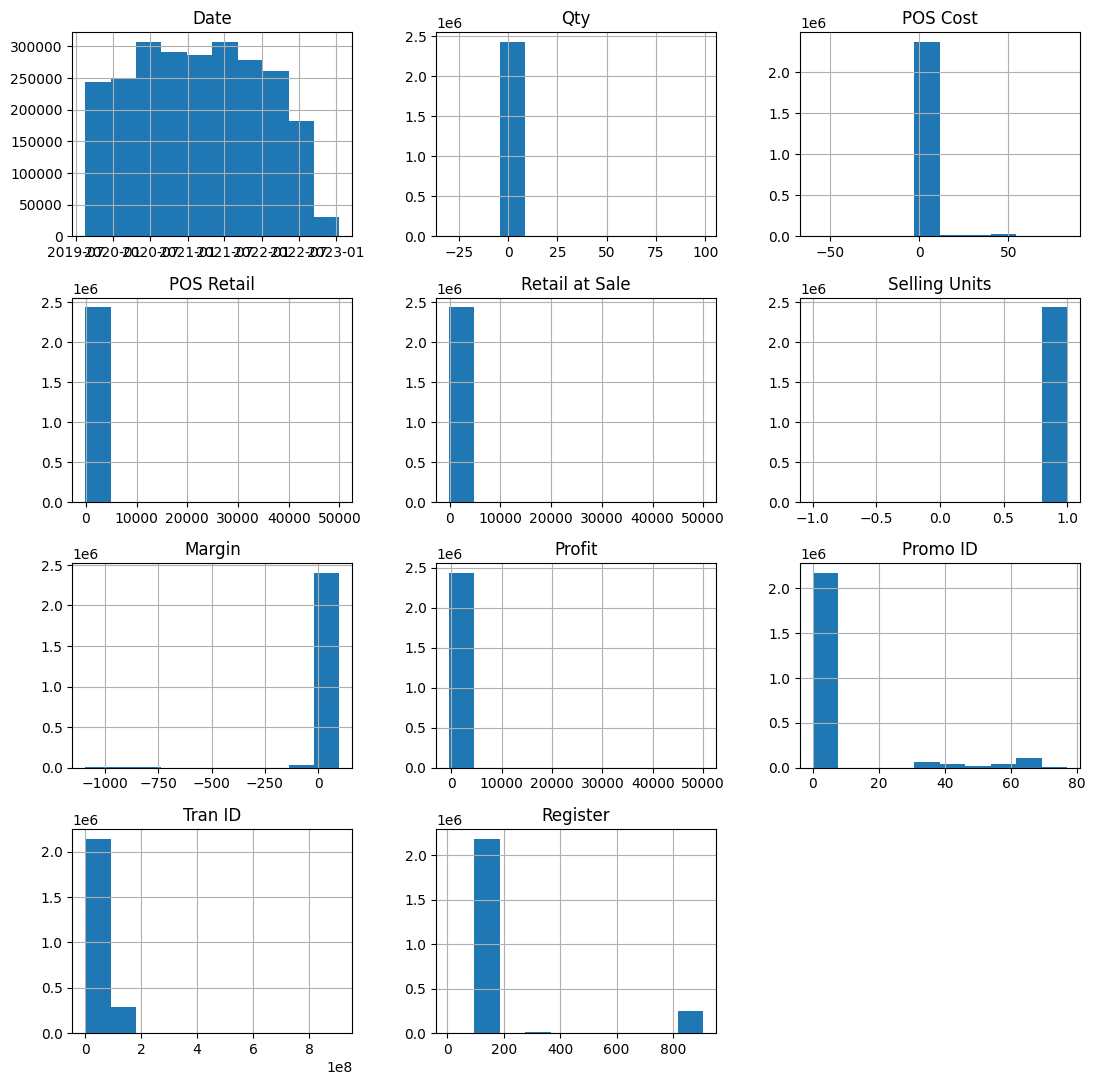

In [ ]:
all_data.hist(figsize = (13,13)) #distribution of each numeric feature
plt.show()

In [ ]:
print(all_data.isnull().sum()) #identify missing values

Date              0
Description       0
Department        0
Qty               0
POS Cost          0
POS Retail        0
Retail at Sale    0
Selling Units     0
Margin            0
Profit            0
Promo ID          0
Tran ID           0
Register          0
dtype: int64


In [ ]:
all_data['Date'] = pd.to_datetime(all_data['Date']) #converts the values in the Date column into a datetime format
print(all_data.dtypes)

Date              datetime64[ns]
Description               object
Department                object
Qty                      float64
POS Cost                 float64
POS Retail               float64
Retail at Sale           float64
Selling Units              int64
Margin                   float64
Profit                   float64
Promo ID                   int64
Tran ID                    int64
Register                   int64
dtype: object


In [ ]:
# Sales calcul
all_data['sales'] = all_data['Qty'] * all_data['POS Retail']
print(all_data.head(5))
data_sales = all_data[["Date",'sales']].set_index("Date")
data_sales

                 Date      Description Department  Qty  POS Cost  POS Retail  \
0 2019-08-15 22:59:34          GROCERY    GROCERY  1.0       0.0        2.99   
1 2019-08-15 22:59:34        PRO FORCE    GROCERY  1.0       0.0        2.99   
2 2019-08-15 22:59:34        PRO FORCE    GROCERY  1.0       0.0        2.99   
3 2019-08-15 22:59:34        PRO FORCE    GROCERY  1.0       0.0        2.99   
4 2019-08-15 23:03:31  TAKIS Diego 9oz    GROCERY  1.0       0.0        2.99   

   Retail at Sale  Selling Units  Margin  Profit  Promo ID  Tran ID  Register  \
0            2.99              1   100.0    2.99         0   198554       904   
1            2.99              1   100.0    2.99         0   198554       904   
2            2.99              1   100.0    2.99         0   198554       904   
3            2.99              1   100.0    2.99         0   198554       904   
4            2.99              1   100.0    2.99         0   573031       101   

   sales  
0   2.99  
1   2.99  

,sales
Date,
2019-08-15 22:59:34,2.99
2019-08-15 22:59:34,2.99
2019-08-15 22:59:34,2.99
2019-08-15 22:59:34,2.99
2019-08-15 23:03:31,2.99
...,...
2023-01-17 07:12:34,6.51
2023-01-17 07:12:40,0.99
2023-01-17 07:12:40,2.29


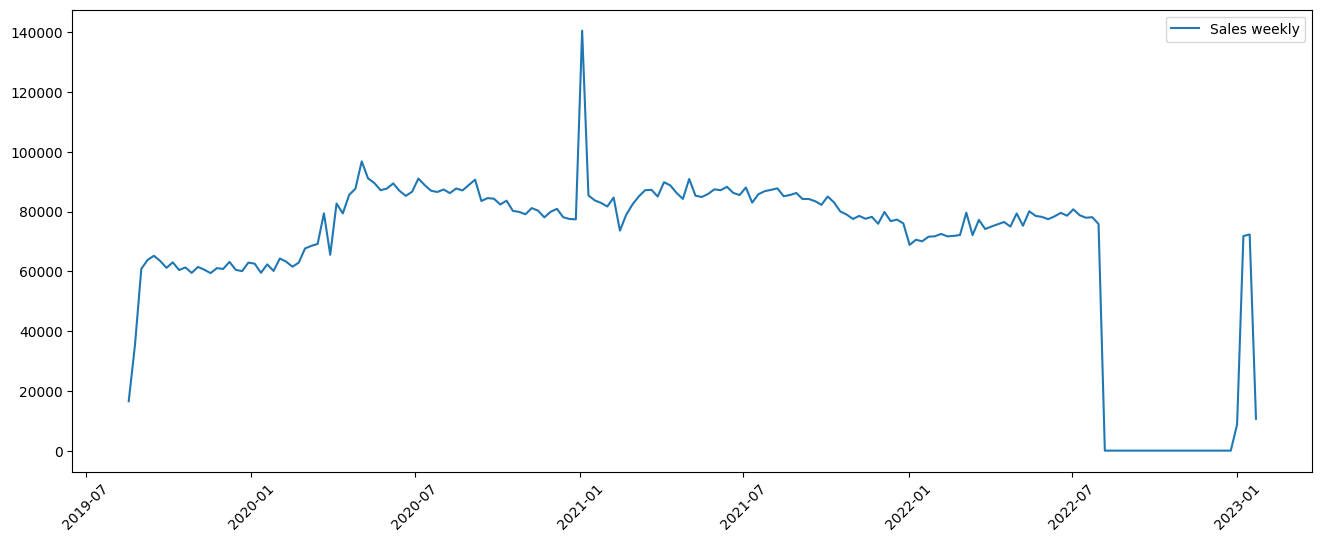

In [ ]:
#
week=data_sales.resample(rule='W').sum()
plt.figure(figsize=(16,6))
plt.plot(week,label='Sales weekly')
plt.xticks(rotation=45)
plt.legend()
plt.show()

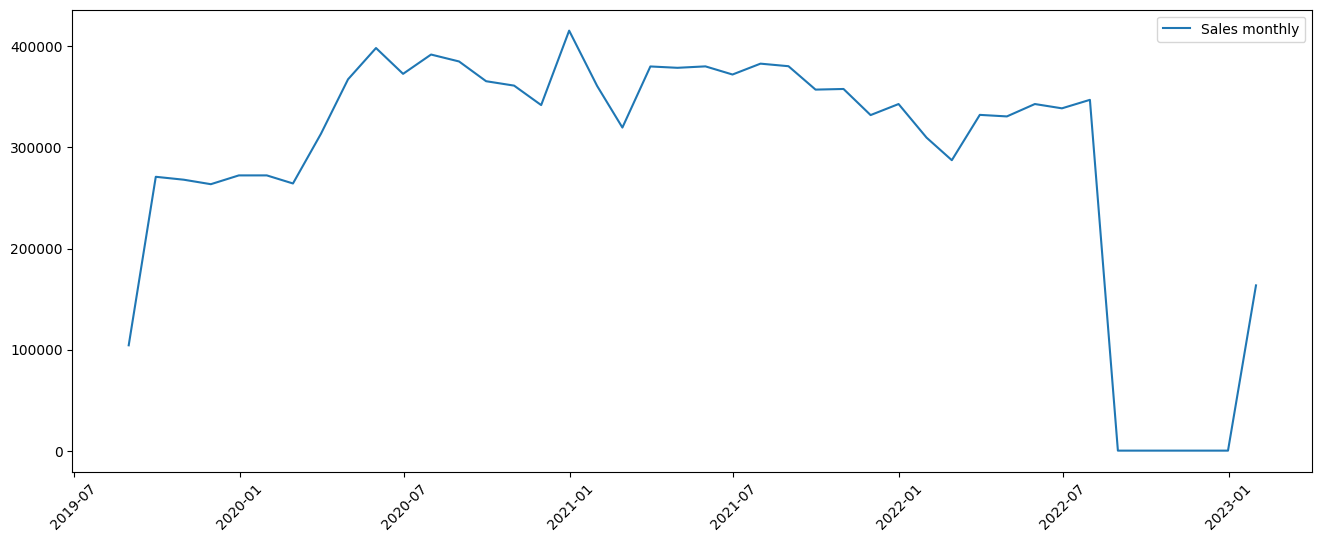

In [ ]:
#Monthly sales
Monthly=data_sales.resample(rule='M').sum()
plt.figure(figsize=(16,6))
plt.plot(Monthly,label='Sales monthly')
plt.xticks(rotation=45)
plt.legend()
plt.show()

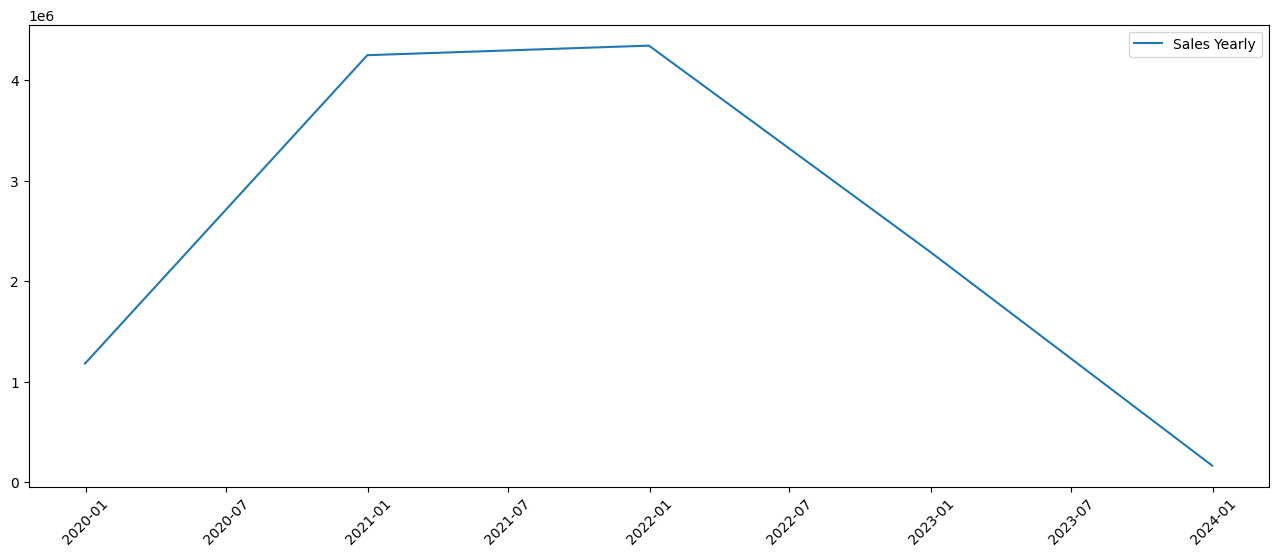

In [ ]:
#Yearly sales
Yearly=data_sales.resample(rule='Y').sum()
plt.figure(figsize=(16,6))
plt.plot(Yearly,label='Sales Yearly')
plt.xticks(rotation=45)
plt.legend()
plt.show()

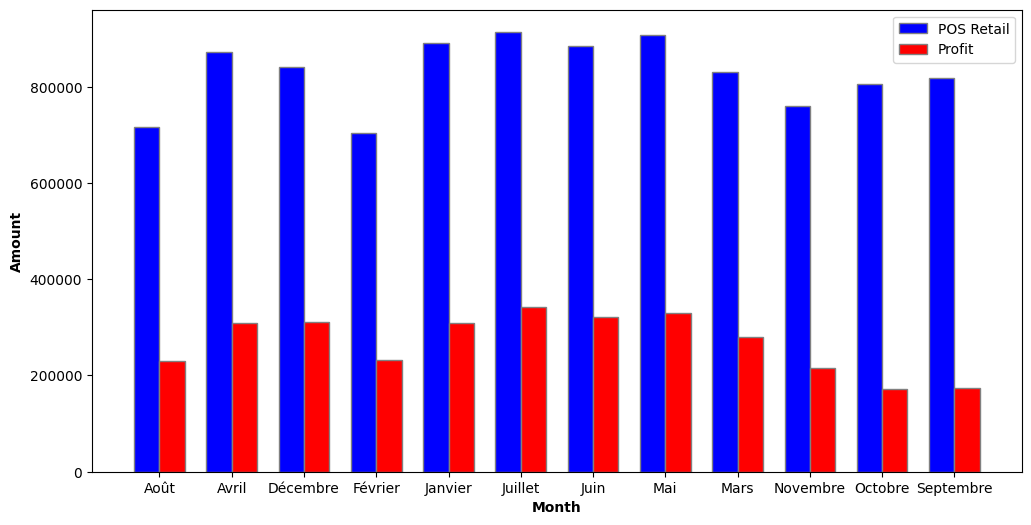

In [ ]:
# Extract the month number from the 'Date' column
all_data['Month'] = all_data['Date'].dt.month

# Define a dictionary to map month numbers to month names
month_names = {
    1: "Janvier", 2: "Février", 3: "Mars", 4: "Avril", 5: "Mai", 6: "Juin",
    7: "Juillet", 8: "Août", 9: "Septembre", 10: "Octobre", 11: "Novembre", 12: "Décembre"
}

# Apply the mapping to convert month numbers to names
all_data['Month Name'] = all_data['Month'].map(month_names)

# Now you can perform your grouping or other operations
monthly_data = all_data.groupby('Month Name').agg({'POS Retail': 'sum', 'Profit': 'sum'}).reset_index()

# Set figure size
plt.figure(figsize=(12, 6))

# Define the width of the bars
bar_width = 0.35

# Set position of bar on X axis
r1 = np.arange(len(monthly_data['Month Name']))
r2 = [x + bar_width for x in r1]

# Make the plot
plt.bar(r1, monthly_data['POS Retail'], color='blue', width=bar_width, edgecolor='grey', label='POS Retail')
plt.bar(r2, monthly_data['Profit'], color='red', width=bar_width, edgecolor='grey', label='Profit')

# Add xticks on the middle of the group bars
plt.xlabel('Month', fontweight='bold')
plt.ylabel('Amount', fontweight='bold')
plt.xticks([r + bar_width/2 for r in range(len(monthly_data['Month Name']))], monthly_data['Month Name'])

# Create legend & Show graphic
plt.legend()
plt.show()


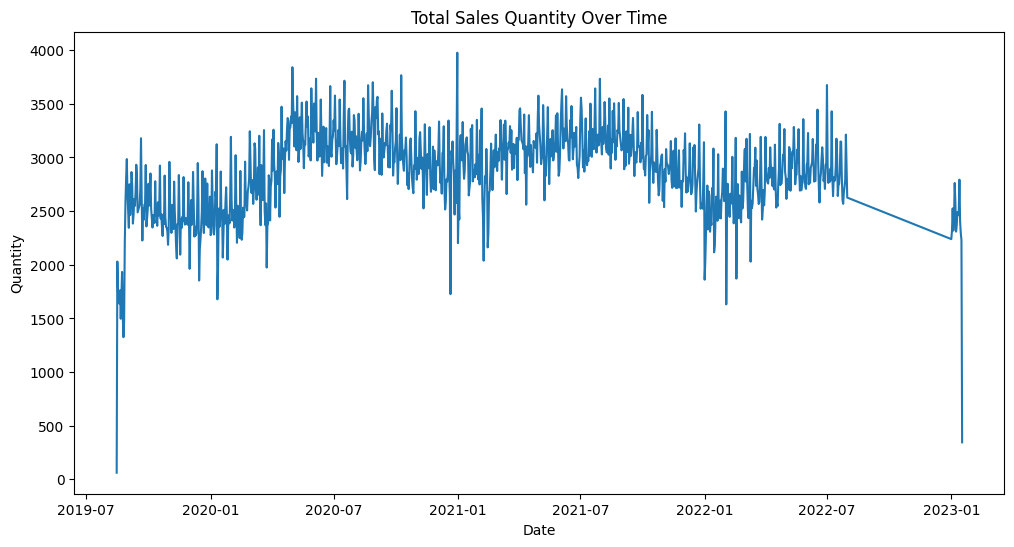

In [ ]:
# Group by Date and calculate total sales quantity per day
daily_sales = all_data.groupby(all_data['Date'].dt.date)['Qty'].sum()
plt.figure(figsize=(12,6))
daily_sales.plot()
plt.title("Total Sales Quantity Over Time")
plt.xlabel("Date")
plt.ylabel("Quantity")
plt.show()

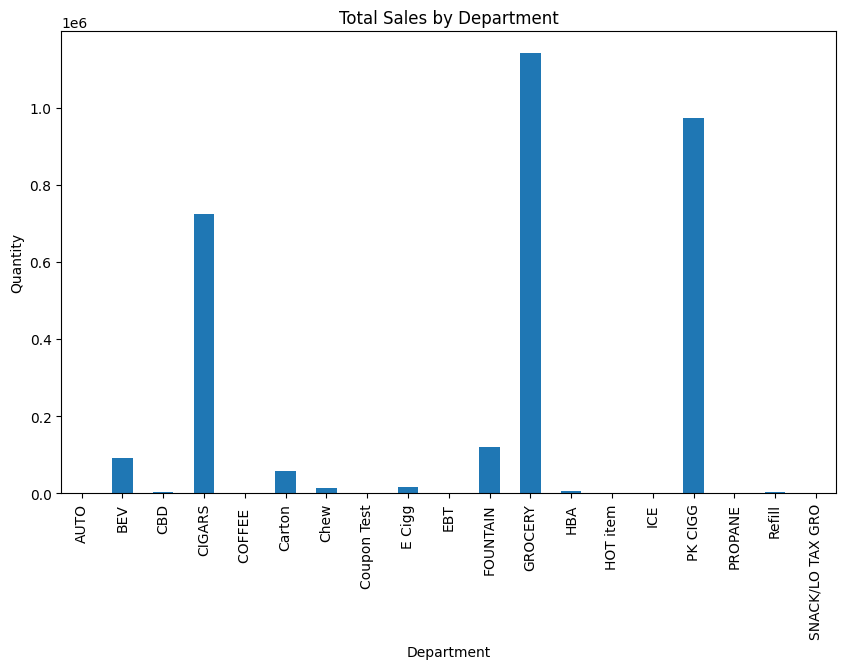

In [ ]:
#understand the distribution of sales across different departments
sales_by_department = all_data.groupby('Department')['Qty'].sum()
sales_by_department.plot(kind='bar', figsize=(10,6))
plt.title("Total Sales by Department")
plt.ylabel("Quantity")
plt.show()

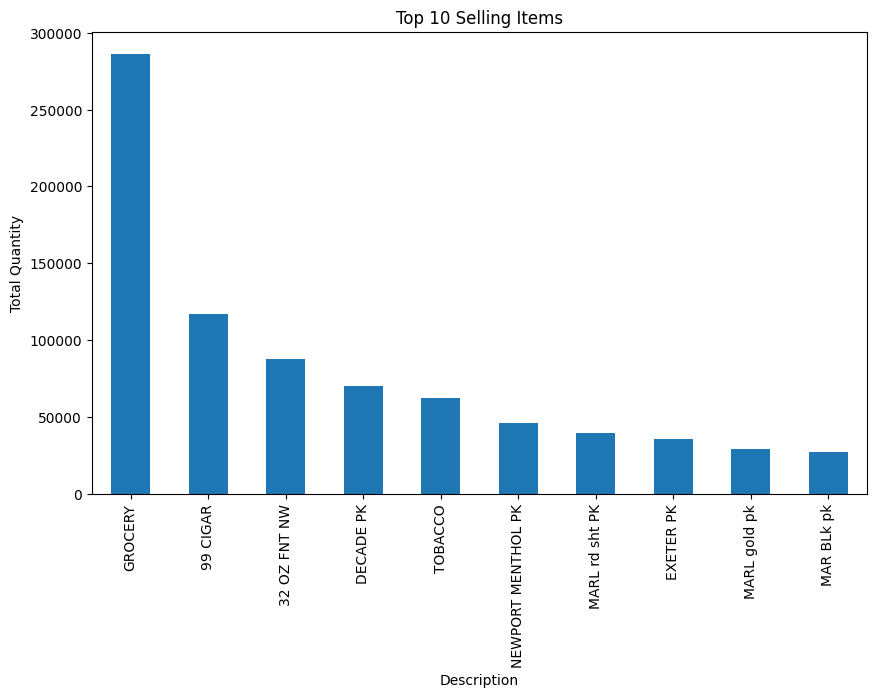

In [ ]:
#identify and visualize the top 10 best-selling items
top_selling_items = all_data.groupby('Description')['Qty'].sum().sort_values(ascending=False).head(10)
top_selling_items.plot(kind='bar', figsize=(10,6))
plt.title("Top 10 Selling Items")
plt.ylabel("Total Quantity")
plt.show()

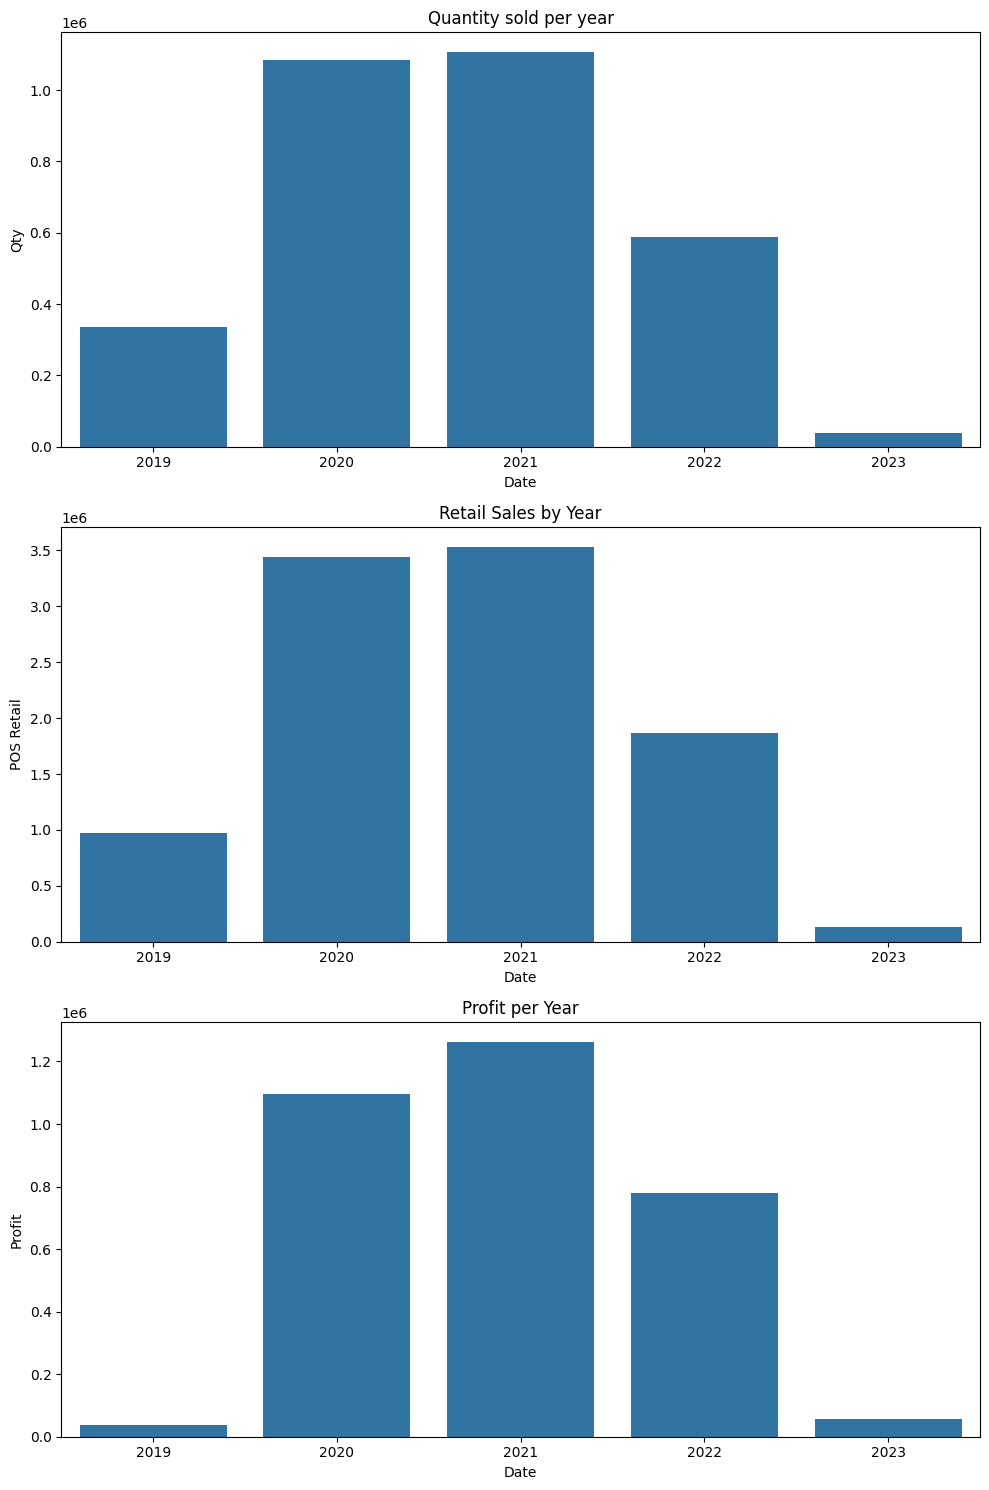

In [ ]:
# Group data by year and calculate the sum for each relevant column
annual_summary = all_data.groupby(all_data['Date'].dt.year).agg({
    'Qty': 'sum',
    'POS Retail': 'sum',
    'Profit': 'sum'
}).reset_index()

# Create graphs to visualize annual data
fig, axes = plt.subplots(3, 1, figsize=(10, 15))
sns.barplot(x='Date', y='Qty', data=annual_summary, ax=axes[0])
sns.barplot(x='Date', y='POS Retail', data=annual_summary, ax=axes[1])
sns.barplot(x='Date', y='Profit', data=annual_summary, ax=axes[2])
axes[0].set_title('Quantity sold per year')
axes[1].set_title('Retail Sales by Year')
axes[2].set_title('Profit per Year')
plt.tight_layout()
plt.show()

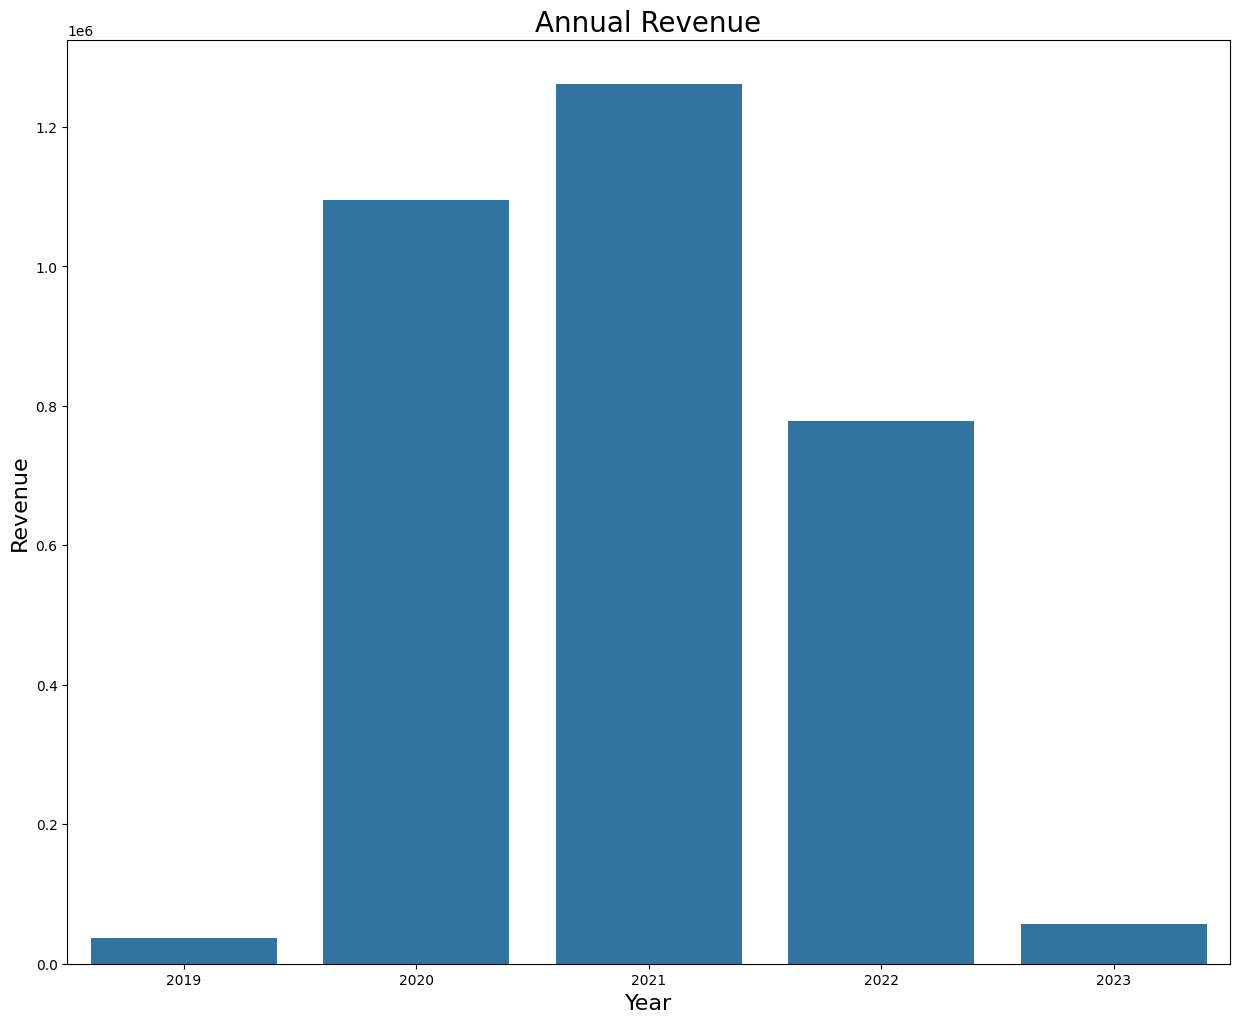

In [ ]:
# Annual Revenue
plt.figure(figsize=(15,12))
annual_profit = all_data.groupby(all_data['Date'].dt.year).agg({'Profit': 'sum'}).reset_index()
# Create graphs to visualize annual data
sns.barplot(x="Date", y="Profit", data=annual_profit)
plt.title('Annual Revenue', fontsize = 20)
plt.xlabel('Year', fontsize = 16)
plt.ylabel('Revenue', fontsize = 16)

plt.show()

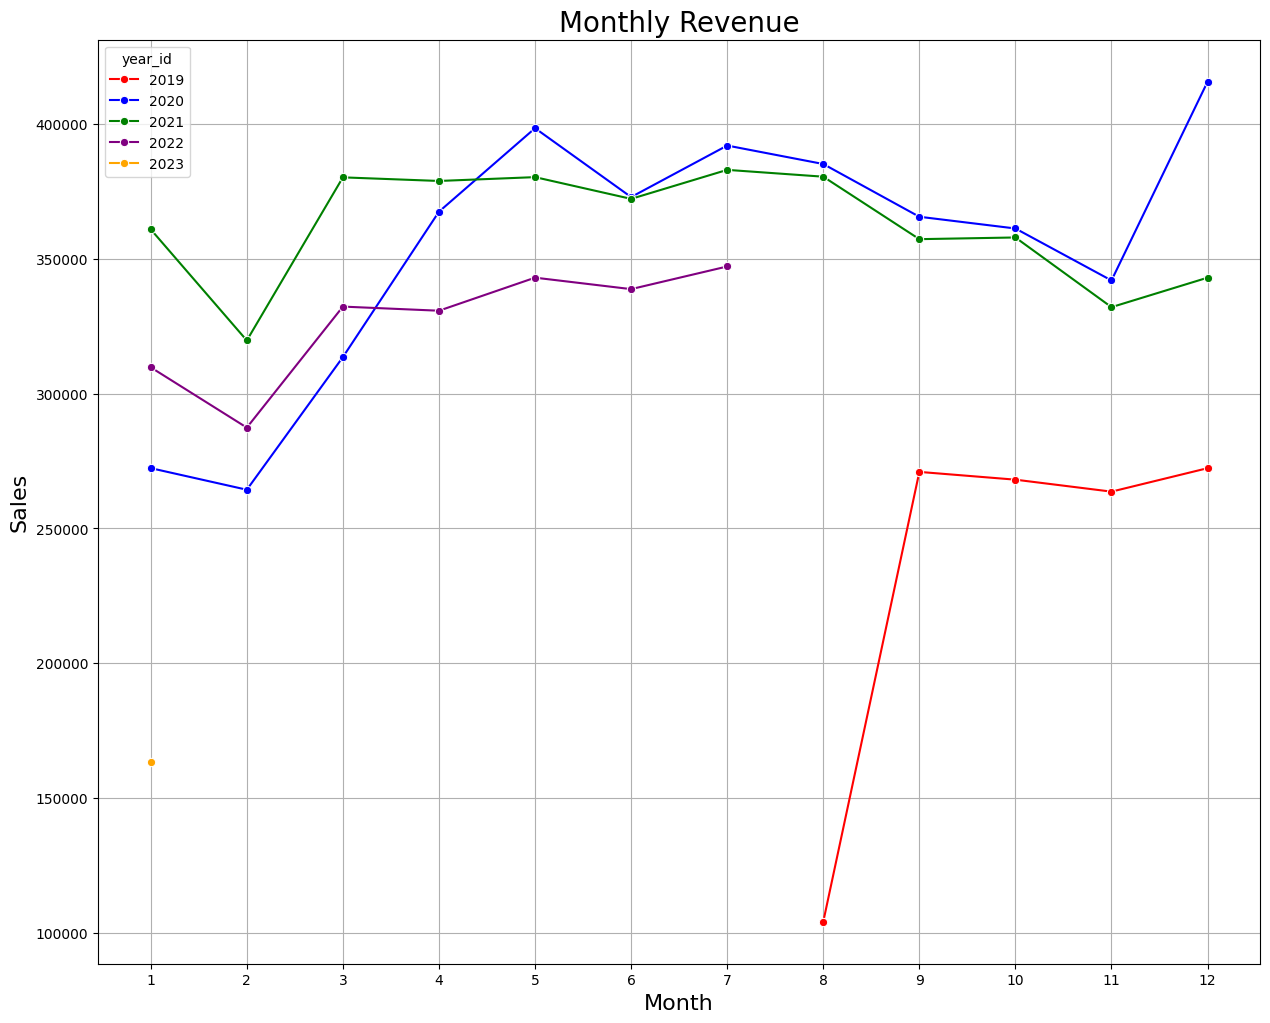

In [ ]:
# Make sure 'Date' is in datetime format
all_data['Date'] = pd.to_datetime(all_data['Date'], errors='coerce')

# Extract year and month
all_data['year_id'] = all_data['Date'].dt.year
all_data['month_id'] = all_data['Date'].dt.month

# Calculation of monthly revenue per year
monthly_revenue = all_data.groupby(['year_id', 'month_id'])['sales'].sum().reset_index()

# Creating a palette that includes all unique years
unique_years = monthly_revenue['year_id'].unique()
colors = ['red', 'blue', 'green', 'purple', 'orange', 'brown']
palette = {year: color for year, color in zip(unique_years, colors)}

# Tracé
plt.figure(figsize=(15, 12))
sns.lineplot(x="month_id", y="sales", hue="year_id", data=monthly_revenue, marker='o', palette=palette)
plt.title('Monthly Revenue', fontsize=20)
plt.xlabel('Month', fontsize=16)
plt.ylabel('Sales', fontsize=16)
plt.xticks(range(1, 13))  # Make sure all months are displayed
plt.grid(True)  # Grids added for better readability

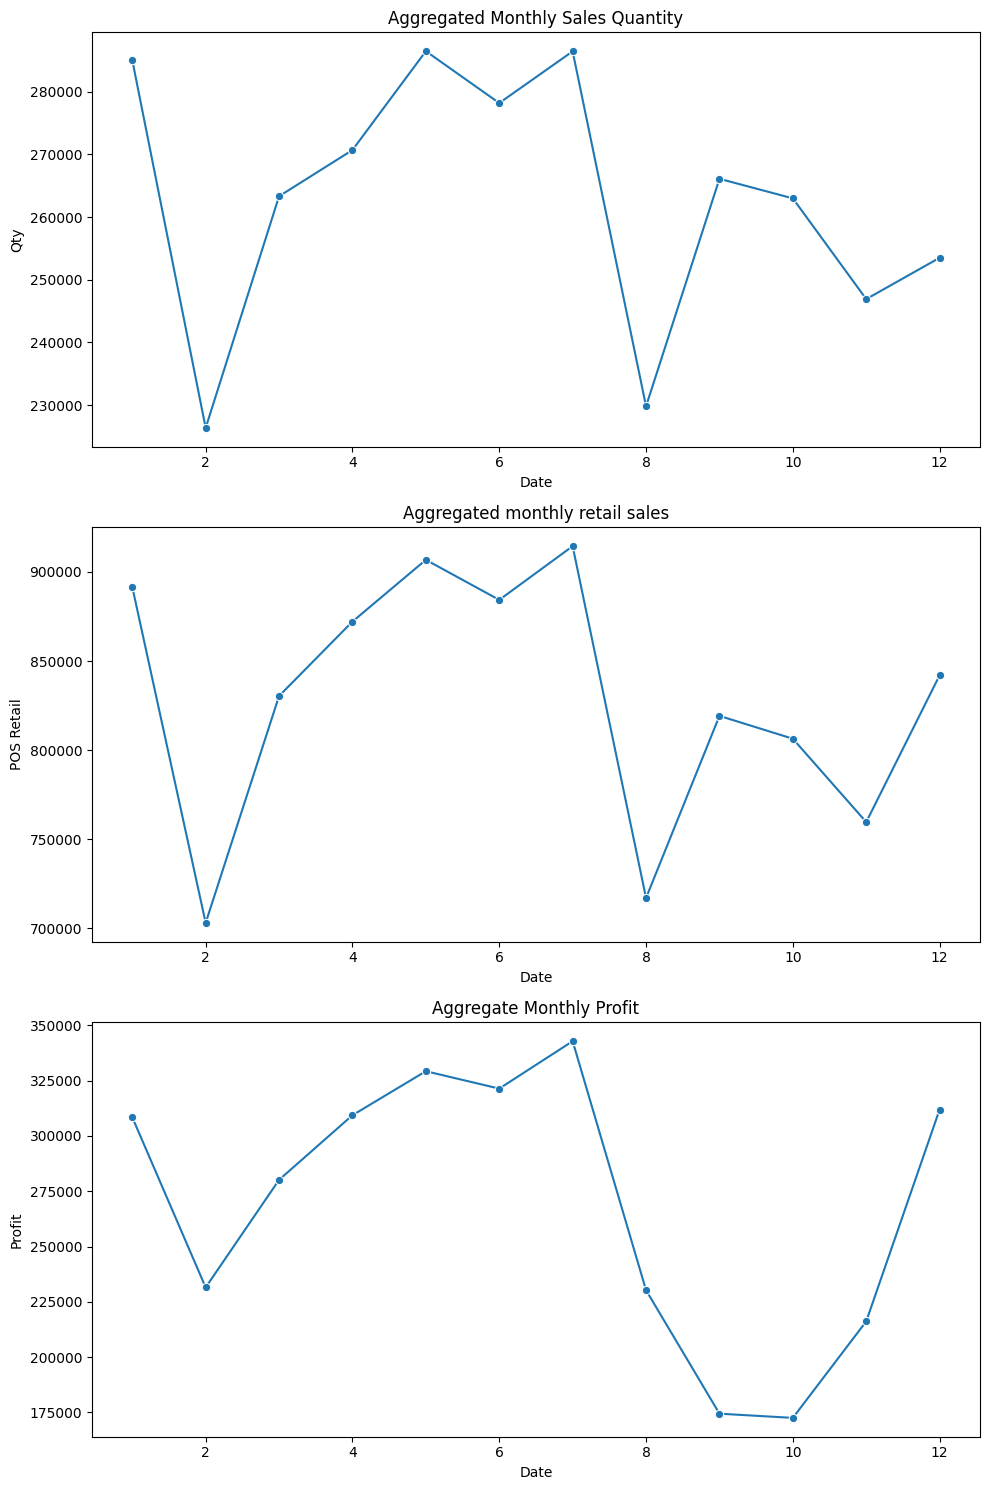

In [ ]:
# Group data by month and calculate the sum for each relevant column
monthly_summary = all_data.groupby(all_data['Date'].dt.month).agg({
    'Qty': 'sum',
    'POS Retail': 'sum',
    'Profit': 'sum'
}).reset_index()
# Create graphs to view aggregated monthly data
fig, axes = plt.subplots(3, 1, figsize=(10, 15))
sns.lineplot(x='Date', y='Qty', data=monthly_summary, ax=axes[0], marker='o')
sns.lineplot(x='Date', y='POS Retail', data=monthly_summary, ax=axes[1], marker='o')
sns.lineplot(x='Date', y='Profit', data=monthly_summary, ax=axes[2], marker='o')
axes[0].set_title('Aggregated Monthly Sales Quantity')
axes[1].set_title('Aggregated monthly retail sales')
axes[2].set_title('Aggregate Monthly Profit')
plt.tight_layout()
plt.show()

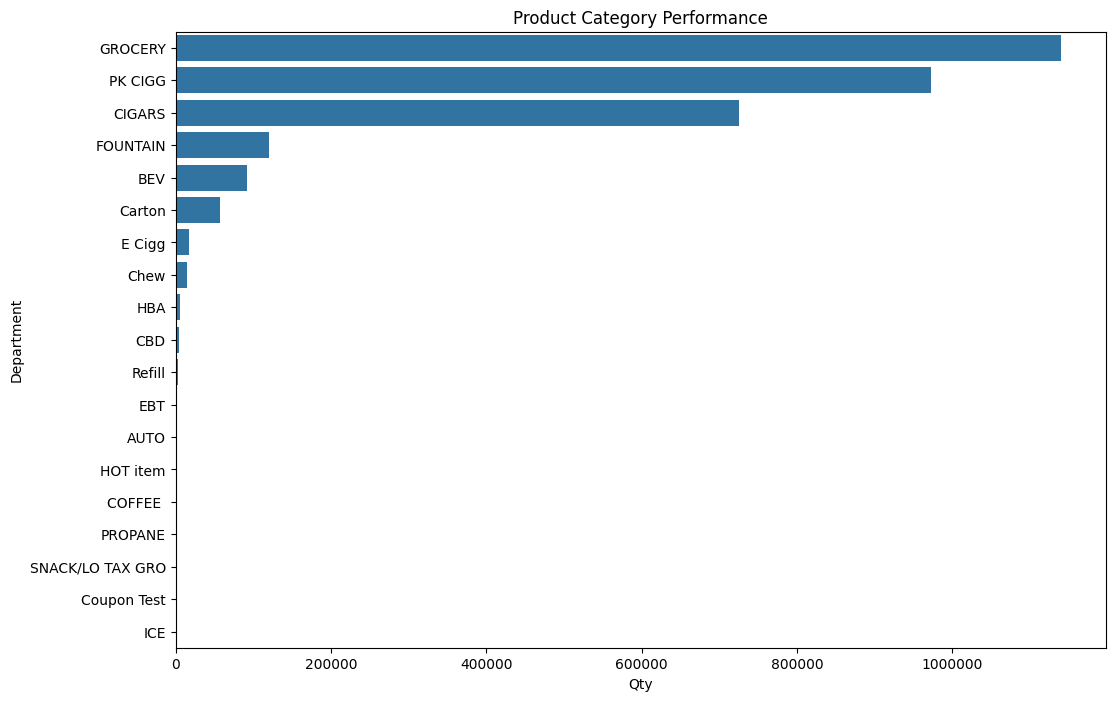

In [ ]:
# Group data by product category and calculate sums
category_performance = all_data.groupby('Department').agg({
    'Qty': 'sum',
    'POS Retail': 'sum',
    'Profit': 'sum'
}).sort_values(by='Qty', ascending=False).reset_index()

# Visualization with bar graphs
fig, ax = plt.subplots(figsize=(12, 8))
sns.barplot(x='Qty', y='Department', data=category_performance, ax=ax)
ax.set_title('Product Category Performance')
# Format the x-axis to display complete numbers
ax.xaxis.set_major_formatter(ticker.StrMethodFormatter('{x:.0f}'))  # No decimals, thousands separator

# For better readability, you can also increase the font size of axis labels.
ax.tick_params(axis='x', labelsize=10)  # Adjust size if necessary
ax.tick_params(axis='y', labelsize=10)

plt.show()

In [ ]:
# Calculate total sums
total_pos_retail = all_data['POS Retail'].sum()
total_profit = all_data['Profit'].sum()

In [ ]:
# Labels and values for the pie chart
labels = ['POS Retail', 'Profit']
values = [total_pos_retail, total_profit]

# Create the pie chart
fig = go.Figure(data=[go.Pie(labels=labels, values=values, textinfo='label+percent',
                             insidetextorientation='radial', marker=dict(line=dict(color='#000000', width=2)))])

# Layout settings
fig.update_layout(title='Sales and profit distribution')

# Plot the figure
iplot(fig)

In [ ]:
# Ensure 'Date' is a datetime object
all_data['Date'] = pd.to_datetime(all_data['Date'], errors='coerce')

# Extract year from 'Date'
all_data['Year'] = all_data['Date'].dt.year

# Group by 'Year' and calculate sums for each financial metric
annual_sums = all_data.groupby('Year').agg({
    'POS Retail': 'sum',
    'Profit': 'sum'
}).reset_index()

In [ ]:

# Determine the number of years (to define the number of subplots)
years = annual_sums['Year'].unique()
num_years = len(years)

# Create subplots: one pie chart per year
fig = make_subplots(rows=1, cols=num_years, specs=[[{'type': 'pie'}]*num_years], subplot_titles=[f'{year}' for year in years])

# Add a pie chart to each subplot
for i, year in enumerate(years, start=1):
    data = annual_sums[annual_sums['Year'] == year]
    values = [data['POS Retail'].values[0], data['Profit'].values[0]]
    labels = ['POS Retail','Profit']

    fig.add_trace(
        go.Pie(labels=labels, values=values, textinfo='label+percent', insidetextorientation='radial'),
        row=1, col=i
    )

# Update layout and plot
fig.update_layout(title_text='Annual Breakdown of Sales and Profits', height=600)
fig.show()


In [ ]:
# Selecting Key Columns and Converting 'Date' to Datetime Format
sales = all_data[['Date','Qty','Retail at Sale','POS Retail','Profit']]
sales['Date'] = pd.to_datetime(sales['Date'])
sales

<ipython-input-31-11bef347827d>:3: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



,Date,Qty,Retail at Sale,POS Retail,Profit
0,2019-08-15 22:59:34,1.0,2.99,2.99,2.990
1,2019-08-15 22:59:34,1.0,2.99,2.99,2.990
2,2019-08-15 22:59:34,1.0,2.99,2.99,2.990
3,2019-08-15 22:59:34,1.0,2.99,2.99,2.990
4,2019-08-15 23:03:31,1.0,2.99,2.99,2.990
...,...,...,...,...,...
483411,2023-01-17 07:12:34,1.0,6.51,6.51,1.094
483412,2023-01-17 07:12:40,1.0,0.99,0.99,0.000
483413,2023-01-17 07:12:40,1.0,2.29,2.29,0.100
483414,2023-01-17 07:13:07,2.0,2.89,2.25,4.500


In [ ]:
# Identifying and Displaying Duplicate Rows in the Sales Data
duplicate_rows = sales[sales.duplicated()]
duplicate_rows.head()

,Date,Qty,Retail at Sale,POS Retail,Profit
1,2019-08-15 22:59:34,1.0,2.99,2.99,2.99
2,2019-08-15 22:59:34,1.0,2.99,2.99,2.99
3,2019-08-15 22:59:34,1.0,2.99,2.99,2.99
46,2019-08-15 23:51:27,1.0,0.99,0.99,0.99
51,2019-08-15 23:52:49,1.0,0.99,0.99,0.99


In [ ]:
sales['Date'] = pd.to_datetime(sales['Date'])
sales.set_index('Date', inplace=True)

<ipython-input-33-099b2a400ec0>:1: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



In [ ]:
monthly_sales = sales['POS Retail'].resample('M').sum()
monthly_sales

,POS Retail
Date,
2019-08-31,89939.589167
2019-09-30,225654.426429
2019-10-31,219632.002667
2019-11-30,214635.398492
2019-12-31,219951.802798
2020-01-31,218117.593810
2020-02-29,213039.542277
2020-03-31,248229.886726
2020-04-30,294758.035810


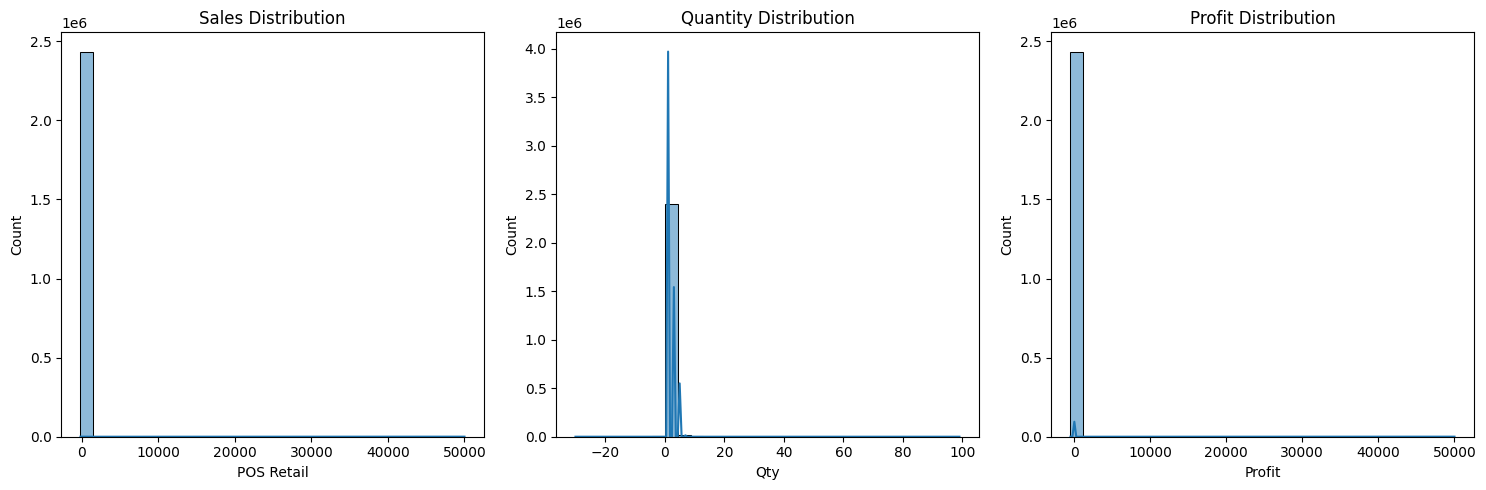

In [ ]:
plt.figure(figsize=(15, 5))

# Sales Distribution
plt.subplot(1, 3, 1)
sns.histplot(sales['POS Retail'], bins=30, kde=True)
plt.title('Sales Distribution')

# Quantity Distribution
plt.subplot(1, 3, 2)
sns.histplot(sales['Qty'], bins=30, kde=True)
plt.title('Quantity Distribution')

# Profit Distribution
plt.subplot(1, 3, 3)
sns.histplot(sales['Profit'], bins=30, kde=True)
plt.title('Profit Distribution')

plt.tight_layout()
plt.show()

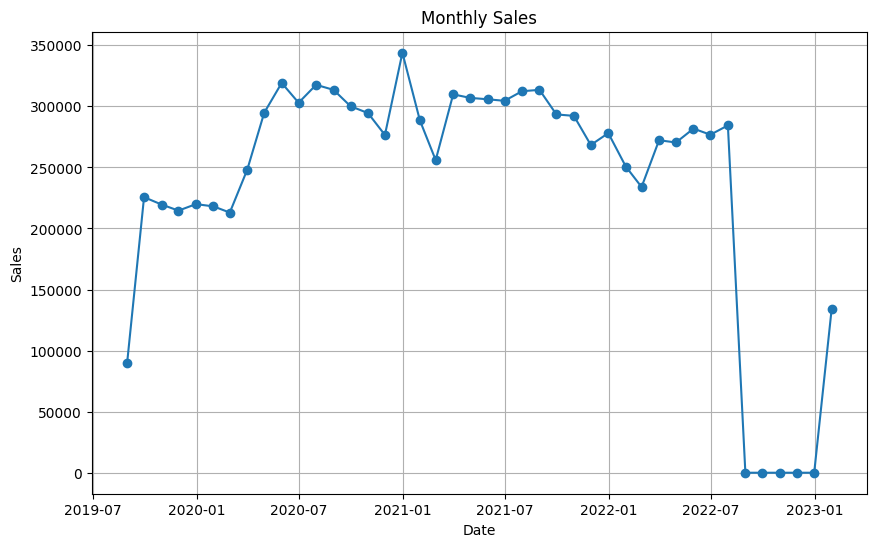

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(monthly_sales.index, monthly_sales.values, marker='o', linestyle='-')
plt.title('Monthly Sales')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.grid(True)
plt.show()

In [ ]:
aggregated.loc["TOBACCO"]

,Description,Qty,POS Cost,POS Retail,Profit
Date,,,,,
2019-08-31,TOBACCOTOBACCOTOBACCOTOBACCOTOBACCOTOBACCOTOBA...,1459.0,0.00,1638.96,2234.02
2019-09-30,TOBACCOTOBACCOTOBACCOTOBACCOTOBACCOTOBACCOTOBA...,2881.0,0.00,2432.70,3721.70
2019-10-31,TOBACCOTOBACCOTOBACCOTOBACCOTOBACCOTOBACCOTOBA...,3278.0,0.00,2931.37,4372.68
2019-11-30,TOBACCOTOBACCOTOBACCOTOBACCOTOBACCOTOBACCOTOBA...,3340.0,1.49,2946.98,4479.91
2019-12-31,TOBACCOTOBACCOTOBACCOTOBACCOTOBACCOTOBACCOTOBA...,3060.0,0.00,2697.44,4191.84
2020-01-31,TOBACCOTOBACCOTOBACCOTOBACCOTOBACCOTOBACCOTOBA...,3711.0,0.00,2847.67,4709.03
2020-02-29,TOBACCOTOBACCOTOBACCOTOBACCOTOBACCOTOBACCOTOBA...,2615.0,8.94,2347.30,3868.77
2020-03-31,TOBACCOTOBACCOTOBACCOTOBACCOTOBACCOTOBACCOTOBA...,4035.0,11.61,2646.04,4921.77
2020-04-30,TOBACCOTOBACCOTOBACCOTOBACCOTOBACCOTOBACCOTOBA...,3797.0,1.49,3055.96,5663.67


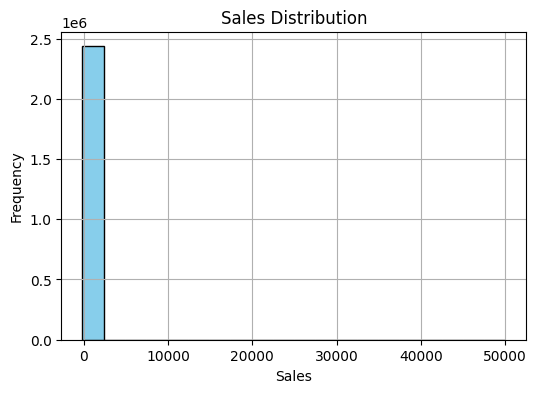

In [ ]:
plt.figure(figsize=(6, 4))
plt.hist(sales['POS Retail'], bins=20, color='skyblue', edgecolor='black')
plt.title('Sales Distribution')
plt.xlabel('Sales')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

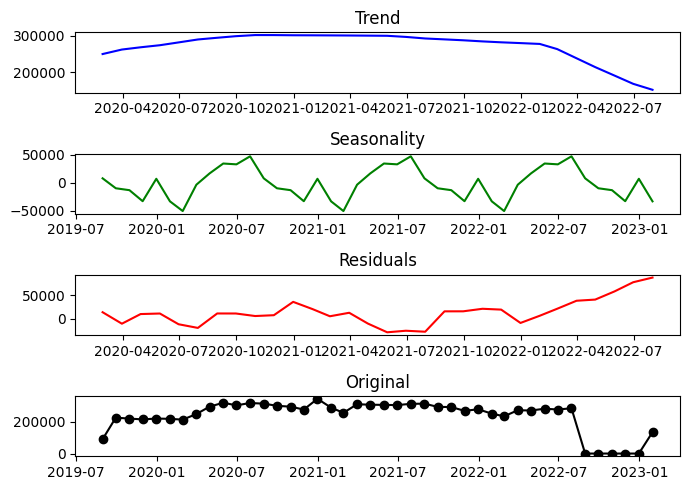

In [ ]:
# Seasonal Decomposition Plot
decomposition = seasonal_decompose(monthly_sales, model='additive')
plt.figure(figsize=(7,5))

plt.subplot(4, 1, 1)
plt.plot(decomposition.trend, label='Trend', color='blue')
plt.title('Trend')

plt.subplot(4, 1, 2)
plt.plot(decomposition.seasonal, label='Seasonality', color='green')
plt.title('Seasonality')

plt.subplot(4, 1, 3)
plt.plot(decomposition.resid, label='Residuals', color='red')
plt.title('Residuals')

plt.subplot(4, 1, 4)
plt.plot(monthly_sales.index, monthly_sales.values, marker='o', linestyle='-', label='Original', color='black')
plt.title('Original')

plt.tight_layout()
plt.show()

In [ ]:
# filter the all_data DataFrame to include only the rows corresponding to the top-selling items
filtered = all_data[all_data["Description"].isin(top_selling_items.index.tolist())].set_index('Date')
filtered

,Description,Department,Qty,POS Cost,POS Retail,Retail at Sale,Selling Units,Margin,Profit,Promo ID,Tran ID,Register,sales,Month,Month Name,year_id,month_id,Year
Date,,,,,,,,,,,,,,,,,,
2019-08-15 22:59:34,GROCERY,GROCERY,1.0,0.000,2.99,2.99,1,100.000000,2.990,0,198554,904,2.99,8,Août,2019,8,2019
2019-08-15 23:06:41,99 CIGAR,CIGARS,1.0,0.000,0.99,0.99,1,100.000000,0.990,0,573032,101,0.99,8,Août,2019,8,2019
2019-08-15 23:07:24,DECADE PK,CIGARS,1.0,0.000,3.04,3.04,1,100.000000,3.040,0,573033,101,3.04,8,Août,2019,8,2019
2019-08-15 23:10:12,GROCERY,GROCERY,1.0,0.000,0.89,0.89,1,100.000000,0.890,0,573034,101,0.89,8,Août,2019,8,2019
2019-08-15 23:10:36,GROCERY,GROCERY,1.0,0.000,0.79,0.79,1,100.000000,0.790,0,573035,101,0.79,8,Août,2019,8,2019
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2023-01-17 06:26:03,GROCERY,GROCERY,1.0,0.000,1.09,1.09,1,100.000000,1.090,0,101263312,101,1.09,1,Janvier,2023,1,2023
2023-01-17 06:29:47,32 OZ FNT NW,FOUNTAIN,1.0,0.990,1.59,1.09,1,37.735849,0.600,0,903133106,903,1.59,1,Janvier,2023,1,2023
2023-01-17 06:41:58,NEWPORT MENTHOL PK,PK CIGG,1.0,7.232,8.58,8.58,1,15.734266,1.348,0,103219304,103,8.58,1,Janvier,2023,1,2023


In [ ]:
 #aggregate the filtered data for the top-selling items on a monthly basis
aggregated = filtered[["Description","Qty","POS Cost","POS Retail","Profit"]].groupby("Description").resample("M").sum()

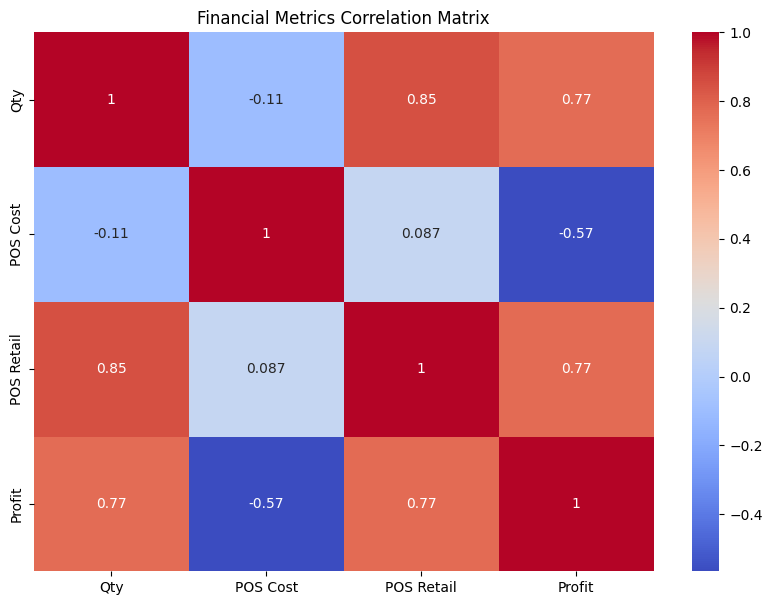

In [ ]:

# Select numeric columns only
numeric_columns = aggregated.select_dtypes(include=['float64', 'int64'])

# Calculate the correlation matrix
correlation_matrix = numeric_columns.corr()

# Display correlation matrix with heatmap
plt.figure(figsize=(10, 7))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.title('Financial Metrics Correlation Matrix')
plt.show()

## SKU

In [ ]:
# Make sure 'Date' is in datetime format
all_data['Date'] = pd.to_datetime(all_data['Date'], errors='coerce')

# Extract temporal information (month and year)
all_data['year'] = all_data['Date'].dt.year
all_data['month'] = all_data['Date'].dt.month

# Group data by SKU (Description) and Period (year, month), and calculate sum of sales (Qty)
sku_sales = all_data.groupby(['Description', 'year', 'month'])['Qty'].sum().reset_index()

# Check first lines
print(sku_sales.head())


          Description  year  month   Qty
0      $2 kool coupon  2020      3   1.0
1  *Hot Tamales Bites  2021      1   1.0
2  *Hot Tamales Bites  2021      2   4.0
3  *Hot Tamales Bites  2021      3  11.0
4  *Hot Tamales Bites  2021      4  12.0


In [ ]:
# Function for detecting declining trends
def detect_declining_trend(sku_sales, sku):
    # Filter data for a specific SKU
    sku_data = sku_sales[sku_sales['Description'] == sku]

    # Convert month and year into a continuous time variable (e.g. year + month/12)
    sku_data['time'] = sku_data['year'] + (sku_data['month'] - 1) / 12.0

    # Use linear regression to estimate sales trends
    X = sku_data[['time']]
    y = sku_data['Qty']

    model = LinearRegression()
    model.fit(X, y)

    # Recover the slope of the regression
    slope = model.coef_[0]

    # If the slope is negative, this can be considered a downward trend.
    return slope < 0, slope



In [ ]:
# Apply decreasing trend detection for each SKU
sku_list = sku_sales['Description'].unique()
declining_skus = []

for sku in sku_list:
    is_declining, slope = detect_declining_trend(sku_sales, sku)
    if is_declining:
        declining_skus.append((sku, slope))



Le flux de sortie a été tronqué et ne contient que les 5000 dernières lignes.
<ipython-input-87-8110764d3495>:7: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

<ipython-input-87-8110764d3495>:7: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

<ipython-input-87-8110764d3495>:7: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user

In [ ]:
# Display SKUs with a declining sales trend
print("SKUs with a declining sales trend :")
for sku, slope in declining_skus:
    print(f"{sku} : Slope = {slope:.4f}")

SKUs with a declining sales trend :
*SR PATCH KIDS HEADS : Slope = -1.1636
*dutch leaf pure 2/1.29 : Slope = -36.4106
00wee pineapple mango : Slope = -3.7975
028400064088 : Slope = -1.8140
028400084048 : Slope = -0.3000
072320710037meiji yan yan vanilla 10/ : Slope = -2.9032
1.00 red man : Slope = -4.8132
100 grand 3pk : Slope = -12.0000
10ozpure apple : Slope = -0.8108
10ozpure orange : Slope = -0.9081
12PAC PEPSICHERR : Slope = -1.1629
16OZ NEW : Slope = -17.2322
16oz body armor strawberry grape : Slope = -19.2857
2 CYCLE : Slope = -15.7143
2-High Hemp Lemonade Cone 15 Ct : Slope = -14.0571
20 OZ FNT NW : Slope = -102.2545
2000 Puffs : Slope = -21.1429
2000 Puffs dragon : Slope = -4.1600
20000 Puffs : Slope = -18.8571
20OZ FNT RE : Slope = -7.1887
20OZ ICE CREAM : Slope = -4.5728
20OZ NEW : Slope = -4.8763
20OZ REFIL : Slope = -1.1403
23.7z pt smtwtr psn frt mng : Slope = -30.0000
24/7 Gk Carton : Slope = -2.1600
24/7 Menthol 100 Bx : Slope = -5.2645
24OZ NEW : Slope = -4.6697
2L Fan

In [ ]:
sku_sales

,Description,year,month,Qty
0,$2 kool coupon,2020,3,1.0
1,*Hot Tamales Bites,2021,1,1.0
2,*Hot Tamales Bites,2021,2,4.0
3,*Hot Tamales Bites,2021,3,11.0
4,*Hot Tamales Bites,2021,4,12.0
...,...,...,...,...
70056,zyn wintergreen 06mg,2022,3,4.0
70057,zyn wintergreen 06mg,2022,4,2.0
70058,zyn wintergreen 06mg,2022,5,2.0
70059,zyn wintergreen 06mg,2022,6,9.0


In [ ]:
sku_sales['Date'] = pd.to_datetime(sku_sales[['year', 'month']].assign(day=1))


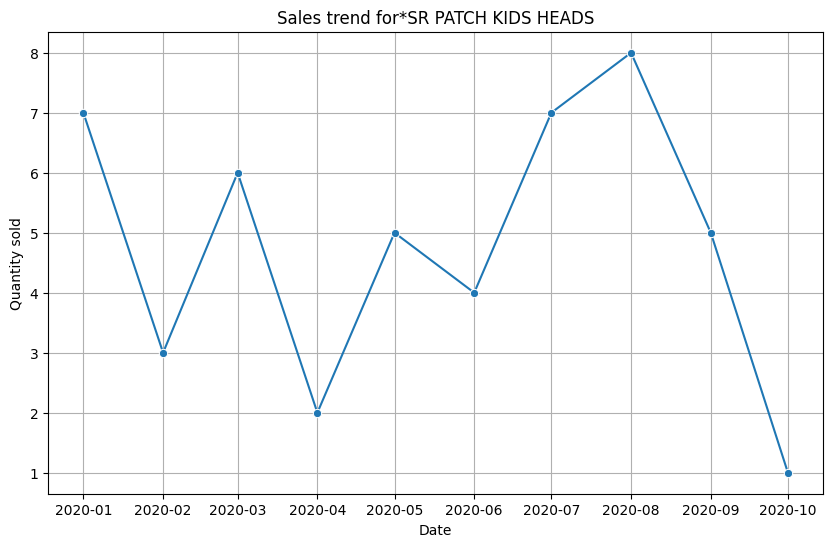

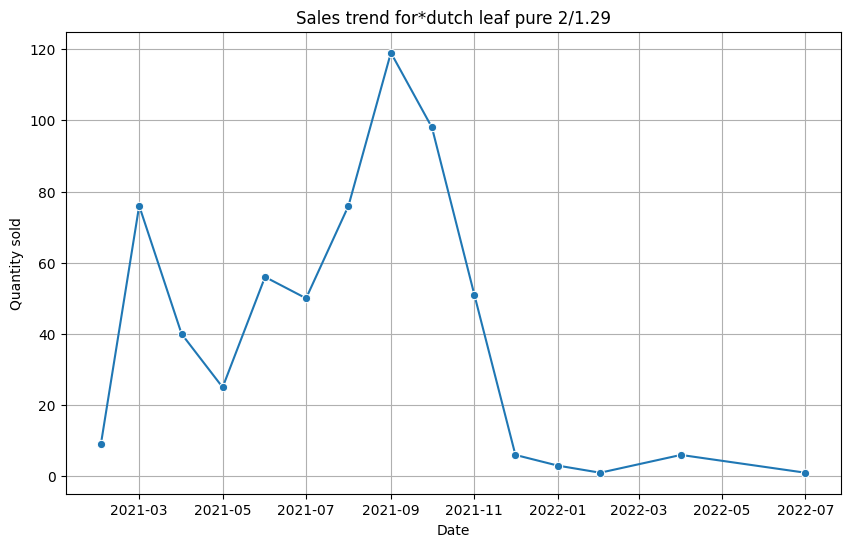

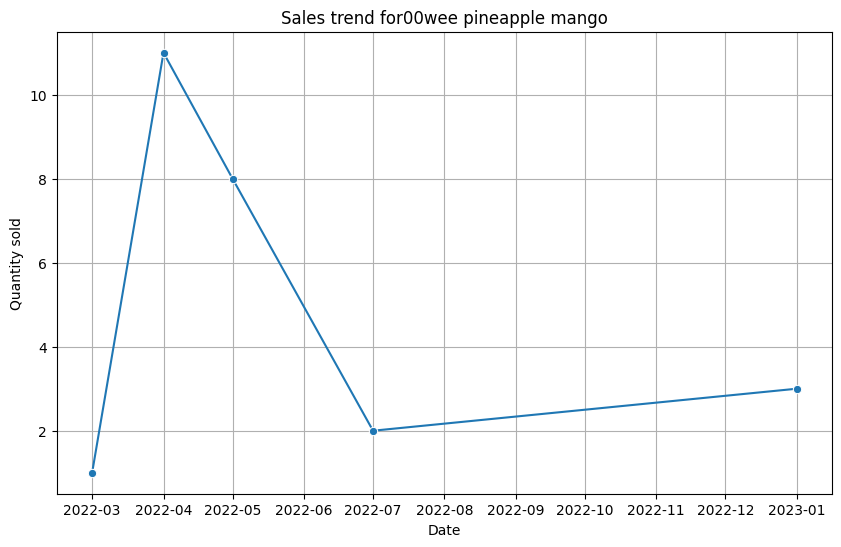

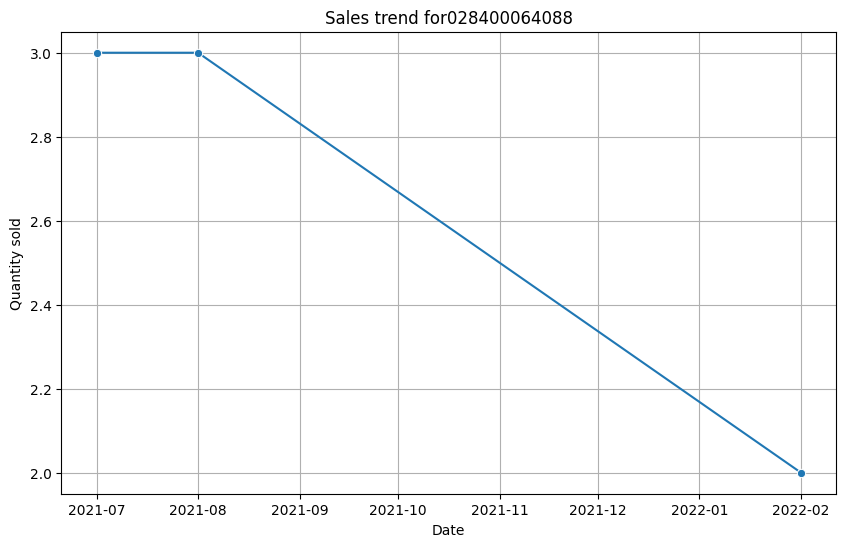

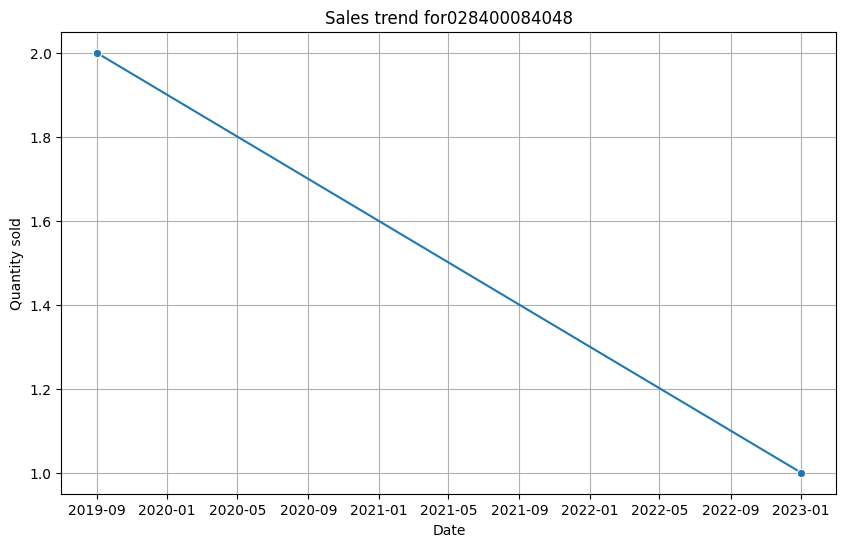

In [ ]:
# Visualize SKUs with a declining trend
for sku, _ in declining_skus[:5]: # Limit display to 5 SKUs for legibility reasons
    sku_data = sku_sales[sku_sales['Description'] == sku]

    # Track sales by period
    plt.figure(figsize=(10, 6))
    sns.lineplot(x='Date', y='Qty', data=sku_data, marker='o')
    plt.title(f"Sales trend for{sku}")
    # plt.xlabel('Period (year + month)')
    plt.ylabel('Quantity sold')
    plt.grid(True)
    plt.show()


## Sales forecasting

In [ ]:
top_selling_items = all_data.groupby('Description')['Qty'].sum().sort_values(ascending=False).head(10)

In [ ]:
data_filtred = all_data[all_data["Description"].isin(top_selling_items.index.tolist())].set_index('Date')
data_filtred

,Description,Department,Qty,POS Cost,POS Retail,Retail at Sale,Selling Units,Margin,Profit,Promo ID,Tran ID,Register,sales,Month,Month Name,year_id,month_id,Year
Date,,,,,,,,,,,,,,,,,,
2019-08-15 22:59:34,GROCERY,GROCERY,1.0,0.000,2.99,2.99,1,100.000000,2.990,0,198554,904,2.99,8,Août,2019,8,2019
2019-08-15 23:06:41,99 CIGAR,CIGARS,1.0,0.000,0.99,0.99,1,100.000000,0.990,0,573032,101,0.99,8,Août,2019,8,2019
2019-08-15 23:07:24,DECADE PK,CIGARS,1.0,0.000,3.04,3.04,1,100.000000,3.040,0,573033,101,3.04,8,Août,2019,8,2019
2019-08-15 23:10:12,GROCERY,GROCERY,1.0,0.000,0.89,0.89,1,100.000000,0.890,0,573034,101,0.89,8,Août,2019,8,2019
2019-08-15 23:10:36,GROCERY,GROCERY,1.0,0.000,0.79,0.79,1,100.000000,0.790,0,573035,101,0.79,8,Août,2019,8,2019
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2023-01-17 06:26:03,GROCERY,GROCERY,1.0,0.000,1.09,1.09,1,100.000000,1.090,0,101263312,101,1.09,1,Janvier,2023,1,2023
2023-01-17 06:29:47,32 OZ FNT NW,FOUNTAIN,1.0,0.990,1.59,1.09,1,37.735849,0.600,0,903133106,903,1.59,1,Janvier,2023,1,2023
2023-01-17 06:41:58,NEWPORT MENTHOL PK,PK CIGG,1.0,7.232,8.58,8.58,1,15.734266,1.348,0,103219304,103,8.58,1,Janvier,2023,1,2023


In [ ]:
 #aggregate the filtered data for the top-selling items on a monthly basis
agg = data_filtred[["Description","Qty","POS Cost","POS Retail","Profit"]].groupby("Description").resample("H").sum()
agg

Description  \
Description  Date                                                                     
32 OZ FNT NW 2019-08-16 06:00:00                           32 OZ FNT NW32 OZ FNT NW   
             2019-08-16 07:00:00   32 OZ FNT NW32 OZ FNT NW32 OZ FNT NW32 OZ FNT NW   
             2019-08-16 08:00:00  32 OZ FNT NW32 OZ FNT NW32 OZ FNT NW32 OZ FNT ...   
             2019-08-16 09:00:00   32 OZ FNT NW32 OZ FNT NW32 OZ FNT NW32 OZ FNT NW   
             2019-08-16 10:00:00  32 OZ FNT NW32 OZ FNT NW32 OZ FNT NW32 OZ FNT ...   
...                                                                             ...   
TOBACCO      2022-07-24 03:00:00                                                  0   
             2022-07-24 04:00:00                                                  0   
             2022-07-24 05:00:00                                                  0   
             2022-07-24 06:00:00                                                  0   
             2022-07-24 07:00:00                                            TOBACCO   

                                  Qty  POS Cost  POS Retail  Profit  
Description  Date                                                    
32 OZ FNT NW 2019-08-16 06:00:00  2.0      0.00        1.78    1.78  
             2019-08-16 07:00:00  4.0      0.00        3.56    3.56  
             2019-08-16 08:00:00  5.0      0.00        4.45    4.45  
             2019-08-16 09:00:00  5.0      0.00        3.56    4.45  
             2019-08-16 10:00:00  7.0      2.67        6.23    3.56  
...                               ...       ...         ...     ...  
TOBACCO      2022-07-24 03:00:00  0.0      0.00        0.00    0.00  
             2022-07-24 04:00:00  0.0      0.00        0.00    0.00  
             2022-07-24 05:00:00  0.0      0.00        0.00    0.00  
             2022-07-24 06:00:00  0.0      0.00        0.00    0.00  
             2022-07-24 07:00:00  1.0      0.59        0.59    0.00  

[290644 rows x 5 columns]

In [ ]:
# If 'Description' is already a column, we delete it before resetting the index.
if 'Description' in agg.columns:
    agg = agg.drop(columns=['Description'])
# Reset index to return 'Description' as column
if 'Description' in agg.index.names:
    agg = agg.reset_index()

# Calculate total quantities sold by category
top_categories = agg.groupby('Description')['Profit'].sum().sort_values(ascending=False).head(10)

# Get the names of the 10 most popular categories
top_category_names = top_categories.index

# Filter data to keep only the top 10 categories
filtered_data = agg[agg['Description'].isin(top_category_names)]

# Check filtered data
print(filtered_data['Description'].unique())


['32 OZ FNT NW' '99 CIGAR' 'DECADE PK' 'EXETER PK' 'GROCERY' 'MAR BLk pk'
 'MARL gold pk' 'MARL rd sht PK' 'NEWPORT MENTHOL PK' 'TOBACCO']


In [ ]:
agg

,Description,Date,Qty,POS Cost,POS Retail,Profit
0,32 OZ FNT NW,2019-08-16 06:00:00,2.0,0.00,1.78,1.78
1,32 OZ FNT NW,2019-08-16 07:00:00,4.0,0.00,3.56,3.56
2,32 OZ FNT NW,2019-08-16 08:00:00,5.0,0.00,4.45,4.45
3,32 OZ FNT NW,2019-08-16 09:00:00,5.0,0.00,3.56,4.45
4,32 OZ FNT NW,2019-08-16 10:00:00,7.0,2.67,6.23,3.56
...,...,...,...,...,...,...
290639,TOBACCO,2022-07-24 03:00:00,0.0,0.00,0.00,0.00
290640,TOBACCO,2022-07-24 04:00:00,0.0,0.00,0.00,0.00
290641,TOBACCO,2022-07-24 05:00:00,0.0,0.00,0.00,0.00
290642,TOBACCO,2022-07-24 06:00:00,0.0,0.00,0.00,0.00


In [ ]:

filtered_data = agg[agg['Description'] == 'GROCERY']

# Vérifier les premières lignes de la nouvelle DataFrame
print(filtered_data.head())


       Description                Date   Qty  POS Cost  POS Retail  Profit
120009     GROCERY 2019-08-15 22:00:00   1.0       0.0        2.99    2.99
120010     GROCERY 2019-08-15 23:00:00  15.0       0.0       38.68   45.26
120011     GROCERY 2019-08-16 00:00:00   6.0       0.0       10.98   10.98
120012     GROCERY 2019-08-16 01:00:00   5.0       0.0       20.47   20.47
120013     GROCERY 2019-08-16 02:00:00  14.0       0.0       32.89   33.88


In [ ]:
# Convertir 'Date' en datetime si ce n'est pas déjà fait
filtered_data['Date'] = pd.to_datetime(filtered_data['Date'])

# Mettre 'Date' comme index
filtered_data.set_index('Date', inplace=True)

# Vérifier la structure après avoir mis 'Date' en index
print(filtered_data.head())



                    Description   Qty  POS Cost  POS Retail  Profit
Date                                                               
2019-08-15 22:00:00     GROCERY   1.0       0.0        2.99    2.99
2019-08-15 23:00:00     GROCERY  15.0       0.0       38.68   45.26
2019-08-16 00:00:00     GROCERY   6.0       0.0       10.98   10.98
2019-08-16 01:00:00     GROCERY   5.0       0.0       20.47   20.47
2019-08-16 02:00:00     GROCERY  14.0       0.0       32.89   33.88


<ipython-input-52-2c1bcc8f5e3e>:2: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



In [ ]:
filtered_data.columns

Index(['Description', 'Qty', 'POS Cost', 'POS Retail', 'Profit'], dtype='object')

In [ ]:
filtered_data.drop('Description', axis=1, inplace=True)
filtered_data.head()

<ipython-input-54-0cc05f43faeb>:1: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



,Qty,POS Cost,POS Retail,Profit
Date,,,,
2019-08-15 22:00:00,1.0,0.0,2.99,2.99
2019-08-15 23:00:00,15.0,0.0,38.68,45.26
2019-08-16 00:00:00,6.0,0.0,10.98,10.98
2019-08-16 01:00:00,5.0,0.0,20.47,20.47
2019-08-16 02:00:00,14.0,0.0,32.89,33.88


In [ ]:
def series_to_supervised(data, n_in=1, n_out=1, dropnan=True):
	n_vars = 1 if type(data) is list else data.shape[1]
	dff = pd.DataFrame(data)
	cols, names = list(), list()
	# input sequence (t-n, ... t-1)
	for i in range(n_in, 0, -1):
		cols.append(dff.shift(i))
		names += [('var%d(t-%d)' % (j+1, i)) for j in range(n_vars)]
	# forecast sequence (t, t+1, ... t+n)
	for i in range(0, n_out):
		cols.append(dff.shift(-i))
		if i == 0:
			names += [('var%d(t)' % (j+1)) for j in range(n_vars)]
		else:
			names += [('var%d(t+%d)' % (j+1, i)) for j in range(n_vars)]
	# put it all together
	agg = pd.concat(cols, axis=1)
	agg.columns = names
	# drop rows with NaN values
	if dropnan:
		agg.dropna(inplace=True)
	return agg


In [ ]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler(feature_range=(0, 1))
scaled = scaler.fit_transform(filtered_data.values)
seq = series_to_supervised(scaled,6,1)
seq.head()

,var1(t-6),var2(t-6),var3(t-6),var4(t-6),var1(t-5),var2(t-5),var3(t-5),var4(t-5),var1(t-4),var2(t-4),...,var3(t-2),var4(t-2),var1(t-1),var2(t-1),var3(t-1),var4(t-1),var1(t),var2(t),var3(t),var4(t)
6,0.030075,0.0,0.110903,0.110547,0.135338,0.0,0.141168,0.146415,0.067669,0.0,...,0.136258,0.136759,0.090226,0.0,0.116101,0.116589,0.105263,0.0,0.124793,0.124446
7,0.135338,0.0,0.141168,0.146415,0.067669,0.0,0.117678,0.117327,0.060150,0.0,...,0.116101,0.116589,0.105263,0.0,0.124793,0.124446,0.165414,0.0,0.121817,0.124913
8,0.067669,0.0,0.117678,0.117327,0.060150,0.0,0.125726,0.125380,0.127820,0.0,...,0.124793,0.124446,0.165414,0.0,0.121817,0.124913,0.097744,0.0,0.123903,0.123555
9,0.060150,0.0,0.125726,0.125380,0.127820,0.0,0.136258,0.136759,0.090226,0.0,...,0.121817,0.124913,0.097744,0.0,0.123903,0.123555,0.203008,0.0,0.140532,0.142715
10,0.127820,0.0,0.136258,0.136759,0.090226,0.0,0.116101,0.116589,0.105263,0.0,...,0.123903,0.123555,0.203008,0.0,0.140532,0.142715,0.097744,0.0,0.122317,0.126025


In [ ]:
seq.info()

<class 'pandas.core.frame.DataFrame'>
Index: 30004 entries, 6 to 30009
Data columns (total 28 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   var1(t-6)  30004 non-null  float64
 1   var2(t-6)  30004 non-null  float64
 2   var3(t-6)  30004 non-null  float64
 3   var4(t-6)  30004 non-null  float64
 4   var1(t-5)  30004 non-null  float64
 5   var2(t-5)  30004 non-null  float64
 6   var3(t-5)  30004 non-null  float64
 7   var4(t-5)  30004 non-null  float64
 8   var1(t-4)  30004 non-null  float64
 9   var2(t-4)  30004 non-null  float64
 10  var3(t-4)  30004 non-null  float64
 11  var4(t-4)  30004 non-null  float64
 12  var1(t-3)  30004 non-null  float64
 13  var2(t-3)  30004 non-null  float64
 14  var3(t-3)  30004 non-null  float64
 15  var4(t-3)  30004 non-null  float64
 16  var1(t-2)  30004 non-null  float64
 17  var2(t-2)  30004 non-null  float64
 18  var3(t-2)  30004 non-null  float64
 19  var4(t-2)  30004 non-null  float64
 20  var1(t-1)  

In [ ]:
features = 4*6
values = seq.values
# 954
n_train_time = 365*24*2 # 365 days, and 24 hours
n_val_time = 365*24*1
train = values[:n_train_time, :]
val = values[n_train_time:n_train_time+n_val_time, :]
test = values[n_train_time+n_val_time:, :]

# split into input and outputs
X_train, y_train = train[:, :-1], train[:, -1]
X_val, y_val = val[:, :-1], val[:, -1]
X_test, y_test = test[:, :-1], test[:, -1]
print(X_train.shape, y_train.shape, X_val.shape, y_val.shape, X_test.shape, y_test.shape)

(17520, 27) (17520,) (8760, 27) (8760,) (3724, 27) (3724,)


## LSTM

In [ ]:
# Importing Required Libraries for Building and Evaluating Deep Learning Models

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import *
from tensorflow.keras.callbacks import ModelCheckpoint,EarlyStopping
from tensorflow.keras.losses import MeanSquaredError
from tensorflow.keras.metrics import RootMeanSquaredError
from sklearn.metrics import r2_score
from tensorflow.keras.optimizers import Adam
import tensorflow as tf
from sklearn.metrics import mean_absolute_error as MAE
from sklearn.metrics import r2_score as R2
from sklearn.metrics import mean_squared_error as MSE
from tensorflow.keras.layers import Input, LSTM, Embedding, Dense,Dropout

In [ ]:
# Reshaping Training, Validation, and Test Data for LSTM Model Input
X_train = X_train.reshape((X_train.shape[0], 1, X_train.shape[1]))
X_val = X_val.reshape((X_val.shape[0], 1, X_val.shape[1]))
X_test = X_test.reshape((X_test.shape[0], 1, X_test.shape[1]))

In [ ]:
# Building an LSTM Model for Regression and Displaying Model Summary
model1 = Sequential()
model1.add(LSTM(32, input_shape=(X_train.shape[1], X_train.shape[2])))
model1.add(Dense(1, activation='linear'))
model1.summary()

/usr/local/lib/python3.10/dist-packages/keras/src/layers/rnn/rnn.py:204: UserWarning:

Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.



Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                          │ (None, 32)                  │           7,680 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 1)                   │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 7,713 (30.13 KB)

 Trainable params: 7,713 (30.13 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Compiling the LSTM Model with Mean Squared Error Loss and Adam Optimizer
model1.compile(loss="MSE",optimizer=Adam(learning_rate=0.0001),metrics=['MAE','MSE'])

In [ ]:
# Training the LSTM Model with Training and Validation Data
history=model1.fit(X_train,y_train,validation_data=(X_val,y_val),batch_size=50,epochs=200)

Epoch 1/200
351/351 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - MAE: 0.0632 - MSE: 0.0054 - loss: 0.0054 - val_MAE: 0.0101 - val_MSE: 1.5705e-04 - val_loss: 1.5705e-04
Epoch 2/200
351/351 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - MAE: 0.0149 - MSE: 4.2347e-04 - loss: 4.2347e-04 - val_MAE: 0.0076 - val_MSE: 1.0032e-04 - val_loss: 1.0032e-04
Epoch 3/200
351/351 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - MAE: 0.0131 - MSE: 3.7981e-04 - loss: 3.7981e-04 - val_MAE: 0.0058 - val_MSE: 6.7926e-05 - val_loss: 6.7926e-05
Epoch 4/200
351/351 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - MAE: 0.0114 - MSE: 2.5977e-04 - loss: 2.5977e-04 - val_MAE: 0.0050 - val_MSE: 5.4233e-05 - val_loss: 5.4233e-05
Epoch 5/200
351/351 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - MAE: 0.0101 - MSE: 1.9731e-04 - loss: 1.9731e-04 - val_MAE: 0.0050 - val_MSE: 4.9888e-05 - val_loss: 4.9888e-05
Epoch 6/200
351/351 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - MAE: 0.0094 - MSE: 1.7397e-04 - loss: 1.7397e-04 - val_MAE: 0.0051 - val_MSE: 4.7279e-05 - val_loss: 4.7279e-05
Epoch 

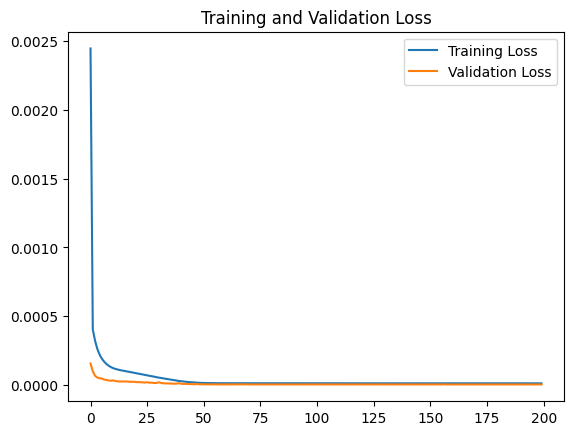

In [ ]:
# Plotting Training and Validation Loss Over Epochs

loss = history.history['loss']
val_loss = history.history['val_loss']

plt.plot(loss, label="Training Loss")
plt.plot(val_loss, label='Validation Loss')
plt.title("Training and Validation Loss")
plt.legend()


In [ ]:
# Generating and Flattening Training Predictions from the LSTM Model
train_predictions=model1.predict(X_train).flatten()
train_predictions.shape

548/548 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


(17520,)

In [ ]:
# Inverse Transforming and Comparing Training Predictions with Actual Values
train_predictions_inverse = scaler.inverse_transform(np.concatenate([X_train[:,0,:3],train_predictions.reshape(-1,1)],axis=1))[:,-1]
train_actuals_inverse = scaler.inverse_transform(np.concatenate([X_train[:,0,:3],y_train.reshape(-1,1)],axis=1))[:,-1]
train_results = pd.DataFrame(data={'Train Predictions':train_predictions_inverse,'Actuals':train_actuals_inverse})
train_results

,Train Predictions,Actuals
0,22.331946,19.37
1,23.183075,19.92
2,20.237181,18.32
3,44.813771,40.90
4,18.445599,21.23
...,...,...
17515,21.941108,20.97
17516,2.306949,1.99
17517,0.677094,0.59
17518,4.110042,3.98


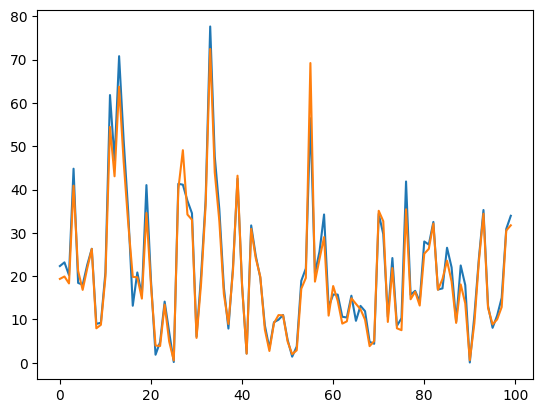

In [ ]:
# Plotting the First 100 Training Predictions and Actual Values
plt.plot(train_results['Train Predictions'][:100])
plt.plot(train_results['Actuals'][:100])

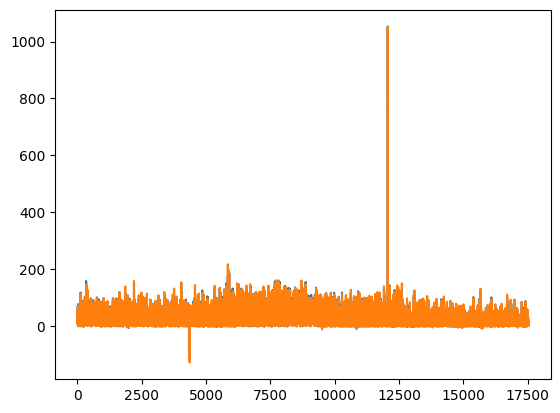

In [ ]:
# Plotting Training Predictions and Actual Values for the Entire Dataset
plt.plot(train_results['Train Predictions'],)
plt.plot(train_results['Actuals'])

In [ ]:
# Inverse Transforming and Comparing Validation Predictions with Actual Values
val_predictions=model1.predict(X_val).flatten()
val_predictions_inverse = scaler.inverse_transform(np.concatenate([X_val[:,0,:3],val_predictions.reshape(-1,1)],axis=1))[:,-1]
val_actuals_inverse = scaler.inverse_transform(np.concatenate([X_val[:,0,:3],y_val.reshape(-1,1)],axis=1))[:,-1]
val_results = pd.DataFrame(data={'Val_Predictions':val_predictions_inverse,'Actuals':val_actuals_inverse})
val_results

274/274 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


,Val_Predictions,Actuals
0,7.425481,6.99
1,5.741284,5.78
2,1.251330,1.09
3,5.692763,5.49
4,13.291523,13.47
...,...,...
8755,-0.254569,0.00
8756,-0.254569,0.00
8757,-0.254569,0.00
8758,-0.254569,0.00


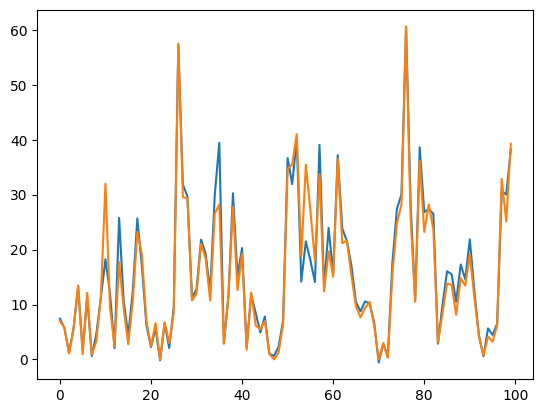

In [ ]:
# Plotting the First 100 Validation Predictions and Actual Values
plt.plot(val_results['Val_Predictions'][:100])
plt.plot(val_results['Actuals'][:100])

In [ ]:
# Inverse Transforming and Comparing Test Predictions with Actual Values
test_predictions=model1.predict(X_test).flatten()
test_predictions_inverse = scaler.inverse_transform(np.concatenate([X_test[:,0,:3],test_predictions.reshape(-1,1)],axis=1))[:,-1]
test_actuals_inverse = scaler.inverse_transform(np.concatenate([X_test[:,0,:3],y_test.reshape(-1,1)],axis=1))[:,-1]
test_results = pd.DataFrame(data={'Test_Predictions':test_predictions_inverse,'Actuals':test_actuals_inverse})
test_results

117/117 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


,Test_Predictions,Actuals
0,-0.254569,0.00
1,-0.254569,0.00
2,-0.254569,0.00
3,-0.254569,0.00
4,-0.254569,0.00
...,...,...
3719,1.576358,1.49
3720,1.359348,1.29
3721,-0.310809,0.00
3722,1.176248,1.09


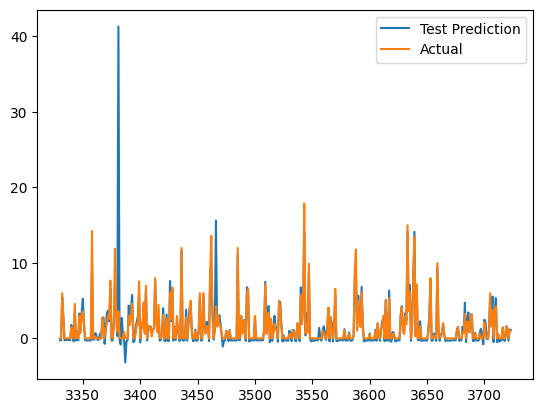

In [ ]:
plt.plot(test_results['Test_Predictions'][3330:],label='Test Prediction')
plt.plot(test_results['Actuals'][3330:],label='Actual')
plt.legend()

In [ ]:
# Calculating and Displaying MAE, R2, and MSE for Training, Testing, and Validation Sets

print("training metrics :")
print("MAE",MAE(train_predictions ,y_train))
print("R2",R2(train_predictions, y_train))
print("MSE",MSE(train_predictions, y_train))

print("------------------------------")
print("testing metrics :")
print("MAE",MAE(test_predictions, y_test))
print("R2",R2(test_predictions, y_test))
print("MSE",MSE(test_predictions, y_test))
print("------------------------------")

print("validation metrics :")
print("MAE",MAE(val_predictions, y_val))
print("R2",R2(val_predictions, y_val))
print("MSE",MSE(val_predictions , y_val))

training metrics :
MAE 0.0020870745508640015
R2 0.9748010765940751
MSE 1.2474081052106527e-05
------------------------------
testing metrics :
MAE 0.00024422393854178347
R2 0.6414047852485472
MSE 3.848921206492144e-07
------------------------------
validation metrics :
MAE 0.0010197088773301842
R2 0.9406770879003636
MSE 4.346044388062043e-06


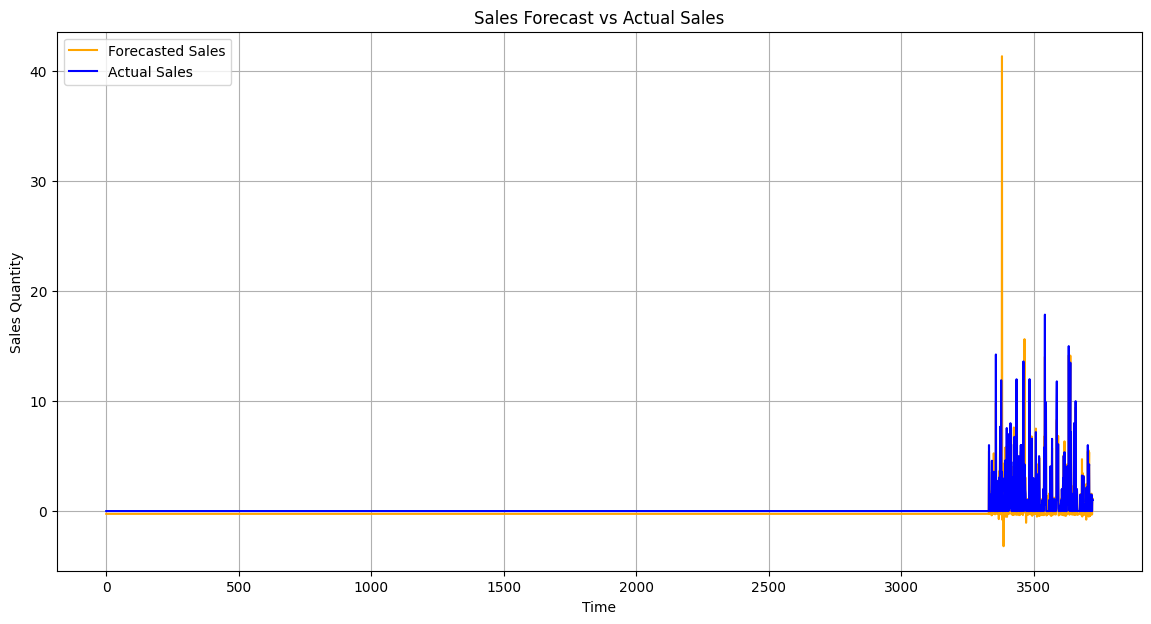

In [ ]:
# Plotting sales forecasts
def plot_forecasts(test_results):
    plt.figure(figsize=(14, 7))
    plt.plot(test_results['Test_Predictions'], label='Forecasted Sales', color='orange')
    plt.plot(test_results['Actuals'], label='Actual Sales', color='blue')
    plt.title('Sales Forecast vs Actual Sales')
    plt.xlabel('Time')
    plt.ylabel('Sales Quantity')
    plt.legend()
    plt.grid()
    plt.show()

# Call the function to plot forecasts
plot_forecasts(test_results)

## prepare a script that will take in new data for the updates. And you can run it as long as new data always has the same structure

Uncomment the following code to update the script according to your new data.


In [ ]:
# def update_model_with_new_data(new_data_path, model, scaler, top_n=10):
#     # Load new data
#     new_data = pd.read_excel(new_data_path)

#     # Combine with existing data
#     all_data = pd.concat([all_data, new_data], axis=0)

#     # Replace missing values in 'Retail at Sale' with the corresponding values in 'POS Retail'
#     all_data['Retail at Sale'] = all_data['Retail at Sale'].fillna(all_data['POS Retail'])

#     # Dropping the 'Scan Code' Column from the Data
#     all_data.drop(['Scan Code'], axis=1, inplace=True)

#     # Filtering top-selling items
#     top_selling_items = all_data.groupby('Description')['Qty'].sum().sort_values(ascending=False).head(top_n)
#     data_filtered = all_data[all_data["Description"].isin(top_selling_items.index.tolist())].set_index('Date')

#     # Aggregate the filtered data for the top-selling items on an hourly basis
#     agg = data_filtered[["Description","Qty","POS Cost","POS Retail","Profit"]].groupby("Description").resample("H").sum()

#     # If 'Description' is already a column, delete it before resetting the index
#     if 'Description' in agg.columns:
#         agg = agg.drop(columns=['Description'])
#     if 'Description' in agg.index.names:
#         agg = agg.reset_index()

#     # Scale the data
#     scaled = scaler.transform(agg.values)

#     # Prepare sequences for LSTM
#     seq = series_to_supervised(scaled, 6, 1)
#     values = seq.values

#     # Split into input and outputs
#     n_train_time = 365*24*2  # Adjust as necessary for the new data
#     train = values[:n_train_time, :]
#     val = values[n_train_time:n_train_time + n_val_time, :]  # Define n_val_time appropriately
#     test = values[n_train_time + n_val_time:, :]

#     X_train, y_train = train[:, :-1], train[:, -1]
#     X_val, y_val = val[:, :-1], val[:, -1]
#     X_test, y_test = test[:, :-1], test[:, -1]

#     # Reshape input for LSTM
#     X_train = X_train.reshape((X_train.shape[0], 1, X_train.shape[1]))
#     X_val = X_val.reshape((X_val.shape[0], 1, X_val.shape[1]))
#     X_test = X_test.reshape((X_test.shape[0], 1, X_test.shape[1]))

#     # Fit the model with the new training data
#     history = model.fit(X_train, y_train, validation_data=(X_val, y_val), batch_size=50, epochs=200)

#     # Return the updated model and training history
#     return model, history


In [ ]:
# # Call the function with the path to your new data and the existing model:

# updated_model, training_history = update_model_with_new_data('/path/to/new_sales_data.xlsx', model1, scaler)
